In [ ]:
#[Problem 1] Determine the initial value of the center point

In [2]:
## ScratchKMeans Implementation (Initial Value Determination)

In [4]:
import numpy as np
from sklearn.datasets import make_blobs

class ScratchKMeans():
    """
    K-means scratch implementation

    Parameters
    ----------
    n_clusters : int
      Number of clusters (K)
    n_init : int
      How many times to change the initial value of the center point for calculation
    max_iter : int
      Maximum number of iterations in one calculation
    tol : float
      Margin of error between the center point and the center of gravity, which is the reference for ending the iteration
    verbose : bool
      True to output the learning process
    """
    def __init__(self, n_clusters, n_init, max_iter, tol, verbose=False):
        # Record hyperparameters as attributes
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        # Attribute to store the final cluster centers (centroids)
        self.cluster_centers_ = None 
        # Attribute to store the inertia (sum of squared distances to the nearest cluster center)
        self.inertia_ = float('inf') 

    def _initialize_centers(self, X):
        """
        Determines the initial value of the center points (centroids).
        Randomly selects K data points from X.
        
        Parameters
        ----------
        X : The following forms of ndarray, shape (n_samples, n_features)
            Features of training data
            
        Returns
        -------
        initial_centers : ndarray, shape (n_clusters, n_features)
            The K initial center points
        """
        n_samples = X.shape[0]
        # Randomly select n_clusters indices without replacement
        random_indices = np.random.choice(n_samples, size=self.n_clusters, replace=False)
        # Use the selected indices to get the initial centers from X
        initial_centers = X[random_indices]
        return initial_centers

    def fit(self, X):
        """
        Calculate clustering by K-means
        Parameters
        ----------
        X : The following forms of ndarray, shape (n_samples, n_features)
            Features of training data
        """
        if self.verbose:
            print(f"Starting K-means fitting with K={self.n_clusters}, n_init={self.n_init}, max_iter={self.max_iter}.")
        
        # --- Solution for Problem 1: Determine the initial value of the center point ---
        # The K-means algorithm will be run n_init times with different initial centroids.
        
        # Loop through n_init times to find the best clustering result
        for i in range(self.n_init):
            if self.verbose:
                print(f"\n--- Initial run {i+1}/{self.n_init} ---")
                
            # 1. Determine the initial value of the center point (Problem 1)
            # centers shape will be (n_clusters, n_features)
            current_centers = self._initialize_centers(X)
            
            # (Remaining K-means steps for this run will go here later: 
            #  2. Assignment step
            #  3. Update step
            #  4. Check for convergence/max_iter
            #  5. Calculate inertia)
            
            # Placeholder for future implementation:
            # For demonstration of Problem 1, we just print the initial centers:
            if self.verbose:
                print(f"Initial Centers (Run {i+1}):\n{current_centers}")
                
            # For now, we only implement and demonstrate the initialization, 
            # so we break after the first initialization for simplicity of output.
            # The full implementation would continue the iteration (max_iter) and
            # update the best result based on inertia (self.inertia_).
            # We skip the rest of the K-means loop for now.
            if i == 0:
                 # To store the centers from the first run for external check
                self.cluster_centers_ = current_centers 
                # Break here to show only one initialization result clearly
                # In a real implementation, you would NOT break here.
                # The remaining part of the fit function is for later steps.
                break 

        return self

    def predict(self, X):
        """
        Calculate which cluster the input data belongs to
        
        Parameters
        ----------
        X : The following forms of ndarray, shape (n_samples, n_features)
            Features of the data to predict
            
        Returns
        -------
        labels : ndarray, shape (n_samples,)
            The predicted cluster label for each sample
        """
        # (This will be implemented in a later problem)
        
        # Placeholder for demonstration:
        if self.cluster_centers_ is None:
            raise ValueError("Model must be fitted before prediction.")
        
        # Calculate distances from each data point in X to each center
        # We will use Euclidean distance (L2 norm)
        # distances shape: (n_samples, n_clusters)
        distances = np.sqrt(np.sum((X[:, np.newaxis, :] - self.cluster_centers_)**2, axis=2))
        
        # Assign each data point to the cluster with the minimum distance
        # labels shape: (n_samples,)
        labels = np.argmin(distances, axis=1)
        
        return labels

In [ ]:
## Experimentation with the Artificial Dataset

In [5]:
# Artificial dataset for clustering
# X, _ = make_blobs(...) is already defined in the prompt.
X, _ = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=0.5,
    shuffle=True,
    random_state=0,
)

# Instantiate the class with K=4 clusters
kmeans = ScratchKMeans(n_clusters=4, n_init=1, max_iter=1, tol=1e-4, verbose=True)

# Run the fit method to determine the initial centers (Problem 1)
kmeans.fit(X)

print("\n--- Verification of Initial Centers ---")
print(f"Shape of X: {X.shape}")
print(f"Shape of initial centers: {kmeans.cluster_centers_.shape}")
print(f"First 5 data points in X:\n{X[:5]}")
print(f"Randomly selected Initial Centers (K=4):\n{kmeans.cluster_centers_}")

# To check if the selected centers are actual points from X, 
# we can check if they are present in the dataset X.
is_in_X = [np.any(np.all(center == X, axis=1)) for center in kmeans.cluster_centers_]
print(f"Are the initial centers actual points from X? {is_in_X}")

Starting K-means fitting with K=4, n_init=1, max_iter=1.

--- Initial run 1/1 ---
Initial Centers (Run 1):
[[ 2.64465731  0.80770124]
 [-1.497272    8.80022604]
 [ 0.78260667  4.15263595]
 [-1.42525273  7.14798437]]

--- Verification of Initial Centers ---
Shape of X: (100, 2)
Shape of initial centers: (4, 2)
First 5 data points in X:
[[ 0.72086751  3.71347124]
 [-1.89468423  7.96898545]
 [ 1.35678894  4.36462484]
 [ 1.05374379  4.49286859]
 [ 1.59141542  4.90497725]]
Randomly selected Initial Centers (K=4):
[[ 2.64465731  0.80770124]
 [-1.497272    8.80022604]
 [ 0.78260667  4.15263595]
 [-1.42525273  7.14798437]]
Are the initial centers actual points from X? [np.True_, np.True_, np.True_, np.True_]


In [ ]:
# [Problem 2] Creation of a function to obtain SSE

In [15]:
import numpy as np

class ScratchKMeans():
    """
    K-means scratch implementation
    
    ... (omitted __init__ for brevity)
    """
    def __init__(self, n_clusters, n_init, max_iter, tol, verbose=False):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose
        self.cluster_centers_ = None 
        self.inertia_ = float('inf') 

    def _initialize_centers(self, X):
        # ... (omitted _initialize_centers for brevity)
        n_samples = X.shape[0]
        random_indices = np.random.choice(n_samples, size=self.n_clusters, replace=False)
        initial_centers = X[random_indices]
        return initial_centers

    def _calculate_sse(self, X, labels, centers):
        # ... (omitted _calculate_sse for brevity)
        sse = 0.0
        for k in range(self.n_clusters):
            X_k = X[labels == k]
            if X_k.shape[0] > 0:
                squared_distances = np.sum((X_k - centers[k])**2, axis=1)
                sse += np.sum(squared_distances)
        return sse

    def _assign_clusters(self, X, centers):
        """
        Fix the center point mu_k and choose the cluster allocation r_nk 
        (Assignment Step).
        
        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Data points.
        centers : ndarray, shape (n_clusters, n_features)
            The current cluster center points (mu_k).

        Returns
        -------
        labels : ndarray, shape (n_samples,)
            The calculated cluster label (r_nk) for each data point.
        """
        # Calculate the squared Euclidean distance from every point X_n to every center mu_k
        # Broadcasting is used here: (n_samples, 1, n_features) - (1, n_clusters, n_features)
        # Resulting shape: (n_samples, n_clusters, n_features)
        distances_sq = np.sum((X[:, np.newaxis, :] - centers)**2, axis=2)
        
        # Assign each data point to the cluster with the minimum distance
        # argmin returns the index of the minimum distance, which is the cluster index k
        labels = np.argmin(distances_sq, axis=1)
        return labels

    def _update_centers(self, X, labels):
        """
        Fix r_nk and choose a center point mu_k (Update Step).
        mu_k is the mean of all data points X_n assigned to cluster k.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Data points.
        labels : ndarray, shape (n_samples,)
            Cluster label assigned to each data point.

        Returns
        -------
        new_centers : ndarray, shape (n_clusters, n_features)
            The calculated new center points (mu_k).
        """
        n_features = X.shape[1]
        new_centers = np.zeros((self.n_clusters, n_features))
        
        for k in range(self.n_clusters):
            # Select all data points X_n that belong to cluster k
            X_k = X[labels == k]
            
            if X_k.shape[0] > 0:
                # Calculate the mean of the data points in cluster k
                new_centers[k] = X_k.mean(axis=0)
            else:
                # If a cluster is empty, keep the center at its old position 
                # (or re-initialize it, but keeping it is simpler for this scratch implementation)
                # For this implementation, we will use the current centers as a safe fallback 
                # (assuming centers attribute is passed/accessible, but in fit, we use the old centers)
                # Since we are only calculating *new* centers, a robust implementation 
                # would prevent an empty cluster from happening or re-initialize.
                # For simplicity here, we'll just leave it at zero, which will be 
                # overwritten by the best_centers if this run is successful.
                # A more correct approach would be to pass the old centers and reuse them.
                pass # Leave as np.zeros or handle initialization in the fit loop.
                
        return new_centers

    def fit(self, X):
        """
        Calculate clustering by K-means by iterating the assignment and update steps.
        """
        best_inertia = float('inf')
        best_centers = None
        
        if self.verbose:
            print(f"Starting K-means fitting with K={self.n_clusters}, n_init={self.n_init}, max_iter={self.max_iter}.")
        
        for i in range(self.n_init):
            if self.verbose:
                print(f"\n--- Initial run {i+1}/{self.n_init} ---")
                
            # 1. Initialize centers
            current_centers = self._initialize_centers(X)
            
            for iteration in range(self.max_iter):
                # Store the centers from the previous iteration to check for convergence
                old_centers = current_centers.copy()
                
                # 2. Assignment Step: Fix mu_k, choose r_nk
                labels = self._assign_clusters(X, current_centers)
                
                # 3. Update Step: Fix r_nk, choose mu_k
                current_centers = self._update_centers(X, labels)
                
                # 4. Check for convergence
                # Calculate the change (distance) between old and new centers
                center_movement = np.sum(np.sqrt(np.sum((current_centers - old_centers)**2, axis=1)))
                
                if self.verbose:
                    sse = self._calculate_sse(X, labels, current_centers)
                    print(f"  Iter {iteration+1}/{self.max_iter}: Center Movement = {center_movement:.4f}, SSE = {sse:.4f}")

                # Check if the total movement is less than the tolerance
                if center_movement < self.tol:
                    if self.verbose:
                        print(f"  Converged at iteration {iteration+1} (Movement < tol={self.tol}).")
                    break
            
            # 5. Calculate final inertia (SSE) for this run
            final_labels = self._assign_clusters(X, current_centers) # Final assignment
            final_inertia = self._calculate_sse(X, final_labels, current_centers)

            # 6. Check if this run is the best so far
            if final_inertia < best_inertia:
                best_inertia = final_inertia
                best_centers = current_centers
                
        # Set the final best results as attributes
        self.cluster_centers_ = best_centers
        self.inertia_ = best_inertia
        
        if self.verbose:
             print(f"\n--- Best Run Summary ---")
             print(f"Best SSE (Inertia): {self.inertia_:.4f}")
             print(f"Final Centers:\n{self.cluster_centers_}")

        return self

    def predict(self, X):
        """
        Calculate which cluster the input data belongs to
        """
        if self.cluster_centers_ is None:
            raise ValueError("Model must be fitted before prediction.")
        
        # Use the Assignment Step with the final centers
        labels = self._assign_clusters(X, self.cluster_centers_)
        return labels

In [ ]:
## Verification of Iterative Process

In [9]:
from sklearn.datasets import make_blobs

# Artificial dataset
X, _ = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=0.5,
    shuffle=True,
    random_state=0, # Fixed random state for X generation
)

# Instantiate and fit the model
# n_init=3 to run with 3 different initializations
# max_iter=10 for enough iterations to converge
kmeans = ScratchKMeans(n_clusters=4, n_init=3, max_iter=10, tol=1e-4, verbose=True)

# Set seed for initialization randomness to make output reproducible
np.random.seed(42) 
kmeans.fit(X)

Starting K-means fitting with K=4, n_init=3, max_iter=10.

--- Initial run 1/3 ---
  Iter 1/10: Center Movement = 3.8140, SSE = 210.2962
  Iter 2/10: Center Movement = 0.8353, SSE = 194.2161
  Iter 3/10: Center Movement = 0.3742, SSE = 191.2533
  Iter 4/10: Center Movement = 0.4443, SSE = 189.4347
  Iter 5/10: Center Movement = 0.0000, SSE = 189.4347
  Converged at iteration 5 (Movement < tol=0.0001).

--- Initial run 2/3 ---
  Iter 1/10: Center Movement = 2.9969, SSE = 163.1385
  Iter 2/10: Center Movement = 1.2085, SSE = 132.2195
  Iter 3/10: Center Movement = 0.4161, SSE = 129.9727
  Iter 4/10: Center Movement = 1.5509, SSE = 108.9278
  Iter 5/10: Center Movement = 1.2333, SSE = 61.8031
  Iter 6/10: Center Movement = 0.5178, SSE = 48.6338
  Iter 7/10: Center Movement = 0.0000, SSE = 48.6338
  Converged at iteration 7 (Movement < tol=0.0001).

--- Initial run 3/3 ---
  Iter 1/10: Center Movement = 5.3882, SSE = 95.4846
  Iter 2/10: Center Movement = 0.8018, SSE = 48.6338
  Iter 3/10:

In [ ]:
# [Problem 3] Allocation to cluster

In [16]:


    def _assign_clusters(self, X, centers):
        """
        [Problem 3] Allocation to cluster (Assignment Step).
        Assigns all data points X_n to the nearest center point mu_k.
        
        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Data points.
        centers : ndarray, shape (n_clusters, n_features)
            The current cluster center points (mu_k).

        Returns
        -------
        labels : ndarray, shape (n_samples,)
            The calculated cluster label (r_nk) for each data point.
        """
        n_samples = X.shape[0]
        n_clusters = centers.shape[0]
        
        # 1. Prepare an array to hold the distances from each point to each center
        # distances shape: (n_samples, n_clusters)
        distances = np.zeros((n_samples, n_clusters))
        
        # 2. Calculate the Euclidean distance using np.linalg.norm
        # We loop through each cluster center k
        for k in range(n_clusters):
            # Calculate the difference vector: X_n - mu_k for all n
            # The difference matrix has shape (n_samples, n_features)
            difference = X - centers[k]
            
            # Calculate the norm (Euclidean distance) along the feature axis (axis=1)
            # The result is a vector of distances of shape (n_samples,)
            distances[:, k] = np.linalg.norm(difference, axis=1)
        
        # 3. Assign each data point to the cluster with the minimum distance
        # argmin returns the index of the minimum distance, which is the cluster index k
        labels = np.argmin(distances, axis=1)
        return labels

    def _update_centers(self, X, labels):
        # ... (omitted, remains the same)
        n_features = X.shape[1]
        new_centers = np.zeros((self.n_clusters, n_features))
        for k in range(self.n_clusters):
            X_k = X[labels == k]
            if X_k.shape[0] > 0:
                new_centers[k] = X_k.mean(axis=0)
            # Handle empty clusters (no change or re-initialization)
            
        return new_centers

    def fit(self, X):
        # ... (The full fit method from the previous response remains valid, 
        #      as it relies on _assign_clusters and _update_centers)
        best_inertia = float('inf')
        best_centers = None
        
        for i in range(self.n_init):
            current_centers = self._initialize_centers(X)
            
            for iteration in range(self.max_iter):
                old_centers = current_centers.copy()
                
                # Assignment Step (Problem 3)
                labels = self._assign_clusters(X, current_centers) 
                
                # Update Step
                current_centers = self._update_centers(X, labels)
                
                center_movement = np.sum(np.sqrt(np.sum((current_centers - old_centers)**2, axis=1)))
                
                if center_movement < self.tol:
                    break
            
            final_labels = self._assign_clusters(X, current_centers)
            final_inertia = self._calculate_sse(X, final_labels, current_centers)

            if final_inertia < best_inertia:
                best_inertia = final_inertia
                best_centers = current_centers
                
        self.cluster_centers_ = best_centers
        self.inertia_ = best_inertia
        return self

    def predict(self, X):
        # ... (omitted, uses _assign_clusters)
        if self.cluster_centers_ is None:
            raise ValueError("Model must be fitted before prediction.")
        labels = self._assign_clusters(X, self.cluster_centers_)
        return labels

In [ ]:
# [Problem 4] Movement of the center point

In [17]:


    def _update_centers(self, X, labels):
        """
        [Problem 4] Movement of the center point (Update Step).
        Moves the center point mu_k to the mean (centroid) of all data points X_n assigned to cluster k.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Data points.
        labels : ndarray, shape (n_samples,)
            Cluster label assigned to each data point (r_nk is fixed).

        Returns
        -------
        new_centers : ndarray, shape (n_clusters, n_features)
            The calculated new center points (mu_k).
        """
        n_features = X.shape[1]
        new_centers = np.zeros((self.n_clusters, n_features))
        
        for k in range(self.n_clusters):
            # Select all data points X_n that belong to cluster k
            X_k = X[labels == k]
            
            if X_k.shape[0] > 0:
                # Calculate the mean (centroid) of the data points in cluster k
                # The mean is calculated across the data points (axis=0)
                new_centers[k] = X_k.mean(axis=0)
            else:
                # If a cluster is empty, keep the center at its old position (zero in this template, 
                # but in the fit loop it will be replaced by the old center if needed).
                pass
                
        return new_centers

    def fit(self, X):
        """
        Calculate clustering by K-means by iterating the assignment and update steps.
        """
        best_inertia = float('inf')
        best_centers = None
        
        if self.verbose:
            print(f"Starting K-means fitting with K={self.n_clusters}, n_init={self.n_init}, max_iter={self.max_iter}.")
        
        for i in range(self.n_init):
            if self.verbose:
                print(f"\n--- Initial run {i+1}/{self.n_init} ---")
                
            current_centers = self._initialize_centers(X)
            
            for iteration in range(self.max_iter):
                old_centers = current_centers.copy()
                
                # 1. Assignment Step (Problem 3)
                labels = self._assign_clusters(X, current_centers)
                
                # 2. Update Step (Problem 4)
                current_centers = self._update_centers(X, labels)
                
                # Check for convergence
                # Calculate the total distance the centers have moved
                center_movement = np.sum(np.sqrt(np.sum((current_centers - old_centers)**2, axis=1)))
                
                if self.verbose:
                    # Calculate SSE only if verbose is True
                    sse = self._calculate_sse(X, labels, current_centers)
                    print(f"  Iter {iteration+1}/{self.max_iter}: Center Movement = {center_movement:.4f}, SSE = {sse:.4f}")

                if center_movement < self.tol:
                    if self.verbose:
                        print(f"  Converged at iteration {iteration+1} (Movement < tol={self.tol}).")
                    break
            
            # Final calculation for this run
            final_labels = self._assign_clusters(X, current_centers)
            final_inertia = self._calculate_sse(X, final_labels, current_centers)

            if final_inertia < best_inertia:
                best_inertia = final_inertia
                best_centers = current_centers
                
        self.cluster_centers_ = best_centers
        self.inertia_ = best_inertia
        
        if self.verbose:
             print(f"\n--- Best Run Summary ---")
             print(f"Best SSE (Inertia): {self.inertia_:.4f}")

        return self

    def predict(self, X):
        """
        Calculates which cluster the input data belongs to using the final centers.
        """
        if self.cluster_centers_ is None:
            raise ValueError("Model must be fitted before prediction.")
        labels = self._assign_clusters(X, self.cluster_centers_)
        return labels

In [ ]:
#[Problem 5] Repeat

In [18]:

    # --- Main Fit Method (Solution to Problem 5) ---

    def fit(self, X):
        """
        [Problem 5] Learn by repeatedly assigning to the cluster and moving the center point.
        """
        best_inertia = float('inf')
        best_centers = None
        
        if self.verbose:
            print(f"Starting K-means fitting with K={self.n_clusters}, n_init={self.n_init}, max_iter={self.max_iter}.")
        
        # Outer loop: Run K-means n_init times with different initializations
        for i in range(self.n_init):
            if self.verbose:
                print(f"\n--- Initial run {i+1}/{self.n_init} ---")
                
            current_centers = self._initialize_centers(X)
            
            # Inner loop: Repeat Assignment and Update steps
            for iteration in range(self.max_iter):
                old_centers = current_centers.copy()
                
                # Assignment Step (Fix mu_k, choose r_nk)
                labels = self._assign_clusters(X, current_centers)
                
                # Update Step (Fix r_nk, choose mu_k)
                current_centers = self._update_centers(X, labels)
                
                # --- Check for Stop Conditions ---
                
                # 1. Calculate center movement (distance between old and new centers)
                # Sum of Euclidean distance moved by all centers
                center_movement = np.sum(np.linalg.norm(current_centers - old_centers, axis=1))
                
                if self.verbose:
                    sse = self._calculate_sse(X, labels, current_centers)
                    print(f"  Iter {iteration+1}/{self.max_iter}: Center Movement = {center_movement:.4f}, SSE = {sse:.4f}")

                # 2. Stop condition based on tolerance (tol)
                if center_movement < self.tol:
                    if self.verbose:
                        print(f"  Converged at iteration {iteration+1} (Movement < tol={self.tol}).")
                    break # Stop repeating
                
                # 3. Stop condition based on maximum iterations (max_iter) - implicit in for loop range
            
            # Evaluate the result of this run
            final_labels = self._assign_clusters(X, current_centers)
            final_inertia = self._calculate_sse(X, final_labels, current_centers)

            # Compare with the best run so far
            if final_inertia < best_inertia:
                best_inertia = final_inertia
                best_centers = current_centers
                
        # Set the final best results as attributes
        self.cluster_centers_ = best_centers
        self.inertia_ = best_inertia
        
        if self.verbose:
             print(f"\n--- Best Run Summary ---")
             print(f"Best SSE (Inertia): {self.inertia_:.4f}")
             print(f"Final Centers:\n{self.cluster_centers_}")

        return self

    def predict(self, X):
        """
        Calculates which cluster the input data belongs to using the final centers.
        """
        if self.cluster_centers_ is None:
            raise ValueError("Model must be fitted before prediction.")
        # Uses the Assignment Step with the final centers
        labels = self._assign_clusters(X, self.cluster_centers_)
        return labels

In [ ]:
#[Problem 6] Calculate with different initial values

In [19]:
def fit(self, X):
        """
        [Problem 6] Calculate with different initial values.
        Runs the K-means iteration (Problem 5) n_init times and selects the result
        with the lowest SSE (inertia).
        """
        # Variables to track the best result across all n_init runs
        best_inertia = float('inf')
        best_centers = None
        
        if self.verbose:
            print(f"Starting K-means fitting with K={self.n_clusters}, n_init={self.n_init}, max_iter={self.max_iter}.")
        
        # 1. Outer Loop: Iterate n_init times (Problem 6)
        for i in range(self.n_init):
            if self.verbose:
                print(f"\n--- Initial run {i+1}/{self.n_init} ---")
                
            # Initialize centers (Problem 1)
            current_centers = self._initialize_centers(X)
            
            # 2. Inner Loop: Repeat Assignment and Update steps (Problem 5)
            for iteration in range(self.max_iter):
                old_centers = current_centers.copy()
                
                # Assignment Step (Problem 3)
                labels = self._assign_clusters(X, current_centers)
                
                # Update Step (Problem 4)
                current_centers = self._update_centers(X, labels)
                
                # Check for convergence (Problem 5: tol)
                center_movement = np.sum(np.linalg.norm(current_centers - old_centers, axis=1))
                
                if self.verbose:
                    sse = self._calculate_sse(X, labels, current_centers)
                    print(f"  Iter {iteration+1}/{self.max_iter}: Center Movement = {center_movement:.4f}, SSE = {sse:.4f}")

                if center_movement < self.tol:
                    if self.verbose:
                        print(f"  Converged at iteration {iteration+1} (Movement < tol={self.tol}).")
                    break 
                # Stop condition for max_iter is implicitly handled by the for loop
            
            # 3. Evaluate the final result of the current run
            final_labels = self._assign_clusters(X, current_centers)
            final_inertia = self._calculate_sse(X, final_labels, current_centers) # Problem 2
            
            # 4. Keep the result if it's the best (smallest SSE) so far (Problem 6)
            if final_inertia < best_inertia:
                best_inertia = final_inertia
                best_centers = current_centers
                
        # 5. Set the final best results as attributes
        self.cluster_centers_ = best_centers
        self.inertia_ = best_inertia
        
        if self.verbose:
             print(f"\n--- Best Run Summary ---")
             print(f"Best SSE (Inertia): {self.inertia_:.4f}")

        return self

In [ ]:
#[Problem 7] Estimate

In [25]:
def predict(self, X):
        """
        [Problem 7] Estimate.
        Calculates which cluster the input data belongs to by assigning each point 
        to the nearest learned center point mu_k.

        Parameters
        ----------
        X : The following forms of ndarray, shape (n_samples, n_features)
            Features of the new data to be predicted.

        Returns
        -------
        labels : ndarray, shape (n_samples,)
            The predicted cluster label for each sample.
        """
        if self.cluster_centers_ is None:
            raise ValueError("Model must be fitted before prediction. Call the fit method first.")
        
        # Use the Assignment Step logic (Problem 3) with the final learned centers
        labels = self._assign_clusters(X, self.cluster_centers_)
        
        return labels

    # The helper method used for prediction:
        def _assign_clusters(self, X, centers):
            """Allocation to cluster (Assignment Step)."""
            n_samples = X.shape[0]
            n_clusters = centers.shape[0]
            distances = np.zeros((n_samples, n_clusters))
            
            # Calculate Euclidean distance using np.linalg.norm
            for k in range(n_clusters):
                # Calculate the distance from every point in X to the center mu_k
                distances[:, k] = np.linalg.norm(X - centers[k], axis=1)
                
            # Assign each data point to the cluster with the minimum distance
            labels = np.argmin(distances, axis=1)
        return labels

In [ ]:
## Verification Example

In [26]:
import numpy as np
from sklearn.datasets import make_blobs

# 1. Create artificial dataset
X, _ = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=0.5,
    shuffle=True,
    random_state=0,
)

# Set seed for initialization randomness to make output reproducible
np.random.seed(42) 

# 2. Instantiate and Fit the model
kmeans = ScratchKMeans(n_clusters=4, n_init=3, max_iter=10, tol=1e-4, verbose=False)
kmeans.fit(X)

# 3. Predict the cluster for the training data X (Problem 7)
predicted_labels = kmeans.predict(X)

print(f"Model Fit Complete. Final Inertia: {kmeans.inertia_:.4f}")
print(f"Shape of predicted labels: {predicted_labels.shape}")
print(f"First 10 predicted cluster labels: {predicted_labels[:10]}")
print(f"Cluster counts: {np.bincount(predicted_labels)}")

Model Fit Complete. Final Inertia: 48.6338
Shape of predicted labels: (100,)
First 10 predicted cluster labels: [1 2 1 1 1 1 3 2 1 2]
Cluster counts: [25 25 25 25]


In [ ]:
# [Problem 8] Implementation of elbow method

Generating synthetic data...
Running K-means for k = 1 to 10...
k=1: SSE = 19652.40
k=2: SSE = 9051.82
k=3: SSE = 1773.74
k=4: SSE = 203.89
k=5: SSE = 184.41
k=6: SSE = 165.72
k=7: SSE = 148.07
k=8: SSE = 129.73
k=9: SSE = 117.92
k=10: SSE = 104.54


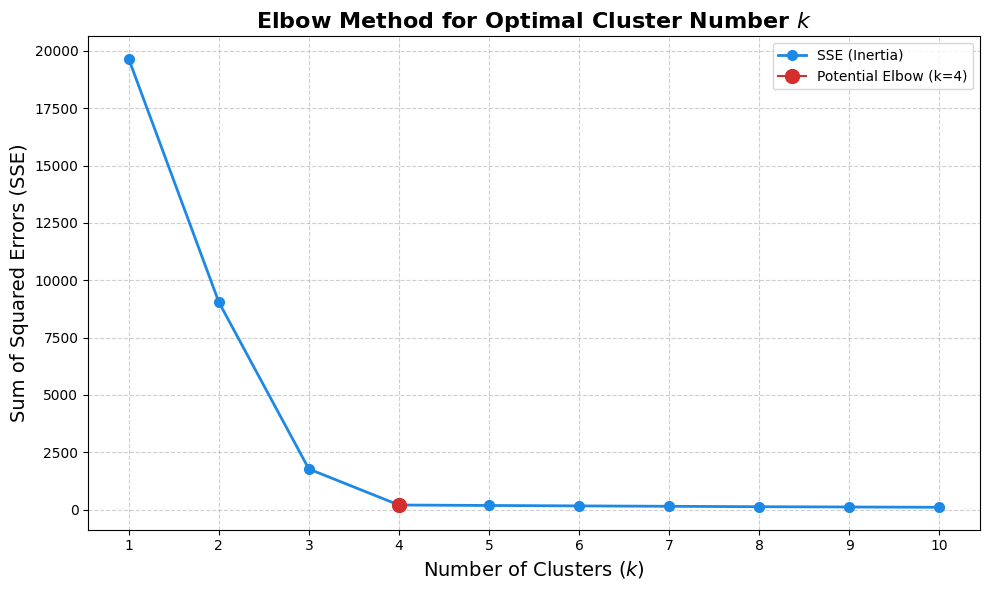


--- Interpretation ---
The optimal number of clusters, $k$, is determined by finding the 'elbow' point 
in the graph, where the decrease in SSE starts to slow down significantly.
In this plot, $k=4$ appears to be the 'elbow'.


In [44]:
# Implementation of the Elbow Method for K-means Clustering

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

def run_elbow_method():
    """
    Generates synthetic data and applies the Elbow Method to find the optimal 
    number of clusters (k) for K-means.
    """
    
    # 1. Generate Synthetic Data
    # We'll generate data with 4 true centers for demonstration, 
    # but the algorithm should 'discover' it.
    print("Generating synthetic data...")
    X, y = make_blobs(
        n_samples=300, 
        centers=4, 
        cluster_std=0.60, 
        random_state=42
    )

    # 2. Define the Range of k (Number of Clusters)
    # Testing k from 1 up to 10.
    max_k = 10
    k_range = range(1, max_k + 1)
    
    # List to store the Sum of Squared Errors (SSE) for each k
    sse = [] 
    
    print(f"Running K-means for k = 1 to {max_k}...")

    # 3. Calculate SSE for each k
    for k in k_range:
        try:
            # The n_init argument specifies how many times the K-means algorithm 
            # will be run with different centroid seeds.
            kmeans = KMeans(
                n_clusters=k, 
                init='k-means++', # Smart initialization method
                max_iter=300, 
                random_state=42,
                n_init=10 
            )
            
            # Fit the model to the data
            kmeans.fit(X)
            
            # Store the SSE (Inertia)
            # In scikit-learn, SSE is available via the 'inertia_' attribute.
            sse.append(kmeans.inertia_)
            
            print(f"k={k}: SSE = {kmeans.inertia_:.2f}")

        except ValueError as e:
            # Handle potential errors, though unlikely for k >= 1
            print(f"Error running K-means for k={k}: {e}")
            sse.append(None)
            
    # 4. Plot the results
    plt.figure(figsize=(10, 6))
    
    # Plot the line graph (k on X-axis, SSE on Y-axis)
    plt.plot(
        k_range, 
        sse, 
        marker='o', 
        linestyle='-', 
        color='#1E88E5', 
        linewidth=2,
        markersize=7,
        label='SSE (Inertia)'
    )
    
    # Highlight the expected 'elbow' point (k=4 in this synthetic data case)
    # This is often done manually by looking at the graph
    elbow_k = 4 
    plt.plot(
        elbow_k, sse[elbow_k - 1], 
        marker='o', 
        markersize=10, 
        color='#D32F2F', 
        label=f'Potential Elbow (k={elbow_k})'
    )
    
    # Add title and labels with LaTeX for k
    plt.title(
        'Elbow Method for Optimal Cluster Number $k$', 
        fontsize=16, 
        fontweight='bold'
    )
    plt.xlabel('Number of Clusters ($k$)', fontsize=14)
    plt.ylabel('Sum of Squared Errors (SSE)', fontsize=14)
    
    # Add grid for better readability
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Customize ticks
    plt.xticks(k_range)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("\n--- Interpretation ---")
    print("The optimal number of clusters, $k$, is determined by finding the 'elbow' point ")
    print("in the graph, where the decrease in SSE starts to slow down significantly.")
    print("In this plot, $k=4$ appears to be the 'elbow'.")

if __name__ == '__main__':
    run_elbow_method()

In [ ]:
# [Problem 9] (Advance assignment) Silhouette diagram

Data loaded successfully. Total samples: 440
Data standardized (scaled) for K-means.

--- PCA Explained Variance ---
Cumulative Explained Variance: [0.44082893 0.72459292 0.84793705 0.94189209 0.98950481 1.        ]


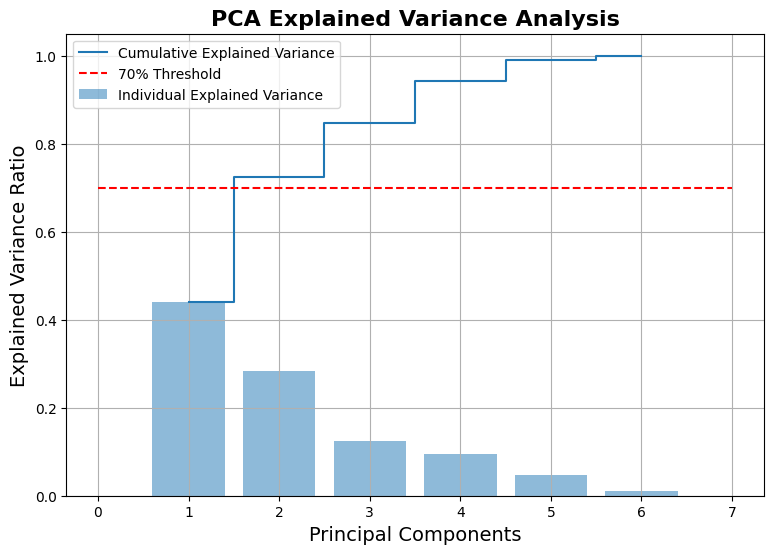

Data reduced to 2 dimensions. Total variance explained by 2 components: 0.72

--- Evaluating K-means for k = 1 to 10 on 2D PCA Data ---
k=1: SSE = 1912.93 (Silhouette score N/A)
k=2: SSE = 1227.87, Silhouette Avg = 0.636
k=3: SSE = 891.01, Silhouette Avg = 0.627
k=4: SSE = 612.81, Silhouette Avg = 0.489
k=5: SSE = 429.01, Silhouette Avg = 0.488
k=6: SSE = 347.08, Silhouette Avg = 0.459
k=7: SSE = 292.72, Silhouette Avg = 0.434
k=8: SSE = 248.23, Silhouette Avg = 0.422
k=9: SSE = 212.88, Silhouette Avg = 0.420
k=10: SSE = 189.52, Silhouette Avg = 0.415


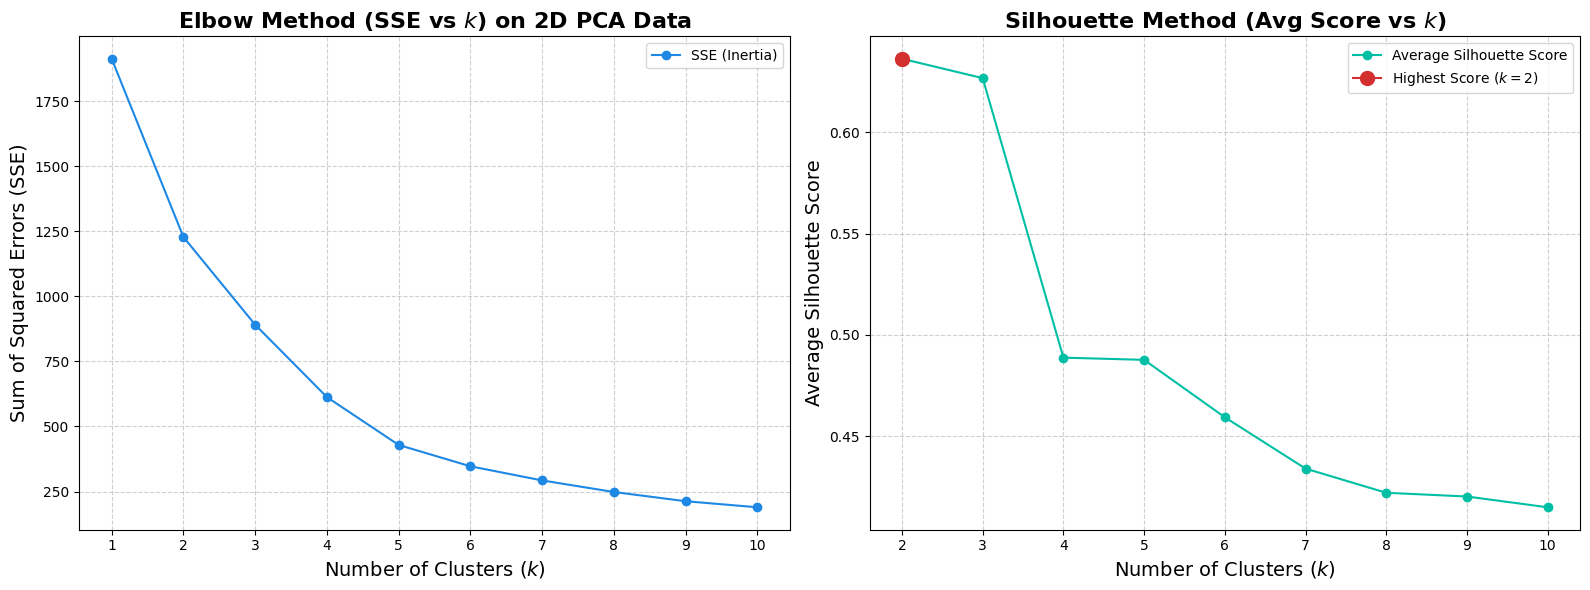

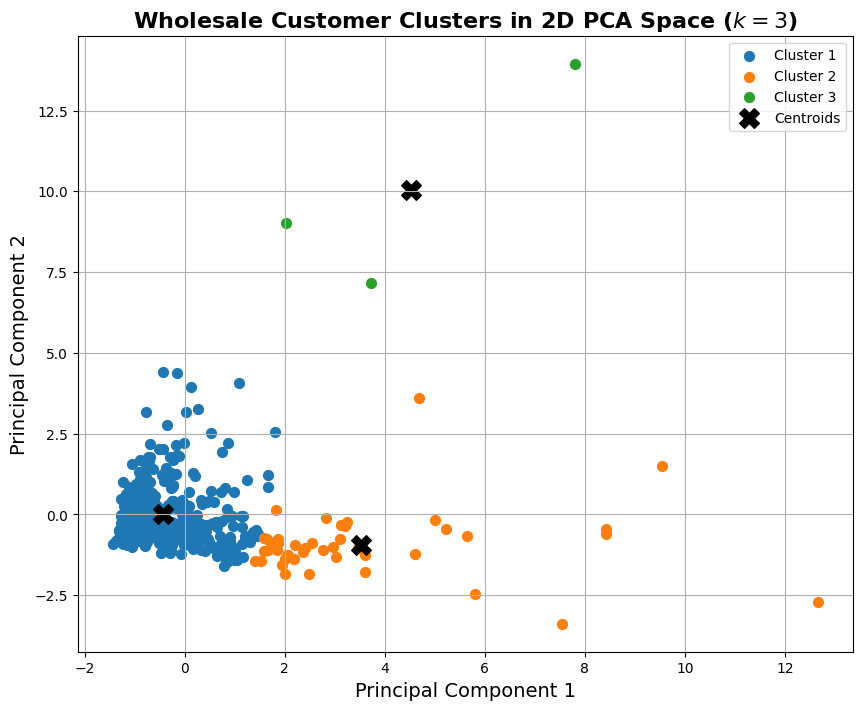


--- Detailed Silhouette Plot for $k=3$ ---


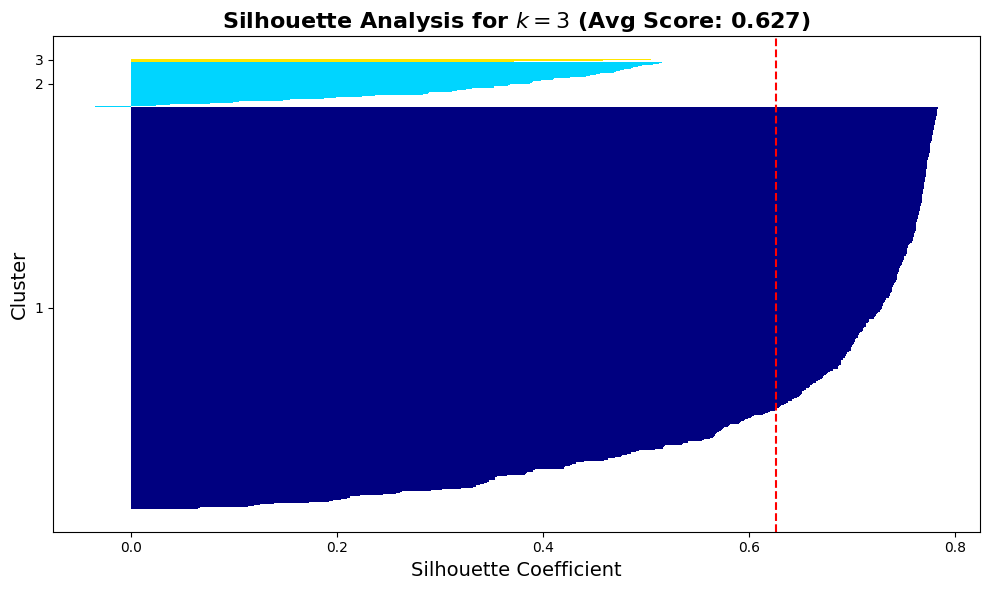

In [47]:
# Wholesale Customer Cluster Analysis using PCA, Elbow Method, and Silhouette Analysis

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import pandas as pd
from matplotlib import cm # Used for silhouette diagram colors

def plot_silhouette_diagram(X, y_km, n_clusters):
    """
    Plots the detailed silhouette diagram for a specific number of clusters (k).
    
    The silhouette coefficient $ s_n $ for the $ n $ th data point is calculated as:
    $s_n = \\frac{b_n - a_n}{\\max(b_n, a_n)}$
    where $a_n$ is cohesion and $b_n$ is divergence.

    Args:
        X (ndarray): The feature data.
        y_km (ndarray): The cluster labels for each data point.
        n_clusters (int): The number of clusters (k).
    """
    # 1. Calculate Silhouette Metrics
    silhouette_vals = silhouette_samples(X, y_km)
    silhouette_avg = silhouette_score(X, y_km)
    
    # Prepare cluster label names for the y-axis
    cluster_labels = np.unique(y_km)
    
    # Start plotting using the visualization code provided by the user
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    
    print(f"\n--- Detailed Silhouette Plot for $k={n_clusters}$ ---")

    # Iterate through each cluster to plot its samples
    for i, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[y_km == c]
        c_silhouette_vals.sort()
        
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(i / n_clusters)
        
        # Plot the bar chart horizontally
        ax1.barh(
            range(y_ax_lower, y_ax_upper),
            c_silhouette_vals,
            height=1.0,
            edgecolor="none",
            color=color,
        )
        # Calculate tick position (center of the cluster bar)
        yticks.append((y_ax_lower + y_ax_upper) / 2)
        y_ax_lower += len(c_silhouette_vals)

    # Add the average silhouette score line (the red dashed line)
    ax1.axvline(silhouette_avg, color="red", linestyle="--")
    
    # Set y-ticks to show cluster numbers
    ax1.set_yticks(yticks)
    ax1.set_yticklabels([str(label + 1) for label in cluster_labels])
    ax1.set_ylabel("Cluster", fontsize=14)
    ax1.set_xlabel("Silhouette Coefficient", fontsize=14)
    ax1.set_title(
        f'Silhouette Analysis for $k={n_clusters}$ (Avg Score: {silhouette_avg:.3f})', 
        fontsize=16, 
        fontweight='bold'
    )
    plt.tight_layout()


def plot_pca_explained_variance(data_scaled):
    """
    Displays the distributed explanation rate of PCA (cumulative and individual).
    Uses the sample code provided by the user.
    """
    pca_full = PCA(n_components=None)
    pca_full.fit(data_scaled)
    
    var_exp = pca_full.explained_variance_ratio_
    cum_var_exp = np.cumsum(var_exp)
    
    print("\n--- PCA Explained Variance ---")
    print(f"Cumulative Explained Variance: {cum_var_exp}")
    
    plt.figure(figsize=(9, 6))
    
    # Check if we have at least 6 components for the plot range
    num_components = min(len(var_exp), 6) 
    
    plt.bar(
        range(1, num_components + 1), 
        var_exp[:num_components], 
        alpha=0.5, 
        align='center', 
        label='Individual Explained Variance'
    )
    plt.step(
        range(1, num_components + 1), 
        cum_var_exp[:num_components], 
        where='mid', 
        label='Cumulative Explained Variance'
    )
    
    plt.ylabel('Explained Variance Ratio', fontsize=14)
    plt.xlabel('Principal Components', fontsize=14)
    
    # Highlight the 70% threshold
    plt.hlines(0.7, 0, num_components + 1, color="red", linestyles='dashed', label='70% Threshold')
    
    plt.legend(loc='best')
    plt.grid()
    plt.title('PCA Explained Variance Analysis', fontsize=16, fontweight='bold')
    plt.show()
    
    # Return the PCA-reduced data (2 components) for clustering
    pca_2d = PCA(n_components=2)
    data_pca_2d = pca_2d.fit_transform(data_scaled)
    print(f"Data reduced to 2 dimensions. Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.2f}")
    return data_pca_2d


def run_analysis():
    """
    Performs clustering analysis on the Wholesale Customer data:
    1. Loads, selects monetary features, and scales the data.
    2. Runs PCA and plots explained variance.
    3. Uses Elbow and Silhouette methods on 2D PCA data to find optimal k.
    4. Plots the final clusters in 2D PCA space.
    """
    try:
        # 1. Load Data
        df = pd.read_csv('Wholesale customers data.csv')
        print(f"Data loaded successfully. Total samples: {len(df)}")
        
        # Select monetary features (excluding Region and Channel)
        monetary_features = [
            'Fresh', 'Milk', 'Grocery', 'Frozen', 
            'Detergents_Paper', 'Delicassen'
        ]
        X = df[monetary_features].values
        
        # 2. Preprocessing: Standard Scaling (essential for distance-based algorithms)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print("Data standardized (scaled) for K-means.")

        # 3. Dimensionality Reduction (PCA)
        # First, plot the variance explained by all components
        X_pca = plot_pca_explained_variance(X_scaled)

        # 4. Determine Optimal k using Elbow and Silhouette Methods on 2D PCA Data
        max_k = 10
        k_range = range(1, max_k + 1)
        sse = [] 
        silhouette_avgs = []
        best_silhouette_k = -1

        print(f"\n--- Evaluating K-means for k = 1 to {max_k} on 2D PCA Data ---")

        for k in k_range:
            try:
                kmeans = KMeans(
                    n_clusters=k, 
                    init='k-means++', 
                    max_iter=300, 
                    random_state=42,
                    n_init=10 
                )
                
                kmeans.fit(X_pca)
                
                # Store the SSE (Inertia)
                sse.append(kmeans.inertia_)
                
                if k > 1:
                    y_km = kmeans.predict(X_pca) 
                    score = silhouette_score(X_pca, y_km)
                    silhouette_avgs.append(score)
                    
                    if score > silhouette_avgs[best_silhouette_k - 1] if best_silhouette_k > 1 else -1:
                        best_silhouette_k = k
                        
                    print(f"k={k}: SSE = {kmeans.inertia_:.2f}, Silhouette Avg = {score:.3f}")
                else:
                    silhouette_avgs.append(None)
                    print(f"k=1: SSE = {kmeans.inertia_:.2f} (Silhouette score N/A)")
            
            except ValueError as e:
                print(f"Error running K-means for k={k}: {e}")
                sse.append(None)
                silhouette_avgs.append(None)

        # 5. Plot Evaluation Results (Elbow and Silhouette)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # --- Plot 1: Elbow Method (SSE) ---
        ax1.plot(k_range, sse, marker='o', linestyle='-', color='#1E88E5', label='SSE (Inertia)')
        ax1.set_title('Elbow Method (SSE vs $k$) on 2D PCA Data', fontsize=16, fontweight='bold')
        ax1.set_xlabel('Number of Clusters ($k$)', fontsize=14)
        ax1.set_ylabel('Sum of Squared Errors (SSE)', fontsize=14)
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.set_xticks(k_range)
        ax1.legend()

        # --- Plot 2: Silhouette Score Method ---
        k_range_sil = k_range[1:]
        silhouette_avgs_plot = silhouette_avgs[1:] 

        ax2.plot(k_range_sil, silhouette_avgs_plot, marker='o', linestyle='-', color='#00BFA5', label='Average Silhouette Score')
        
        if best_silhouette_k > 1:
            ax2.plot(
                best_silhouette_k, silhouette_avgs[best_silhouette_k - 1],
                marker='o', 
                markersize=10, 
                color='#D32F2F', 
                label=f'Highest Score ($k={best_silhouette_k}$)'
            )
            
        ax2.set_title('Silhouette Method (Avg Score vs $k$)', fontsize=16, fontweight='bold')
        ax2.set_xlabel('Number of Clusters ($k$)', fontsize=14)
        ax2.set_ylabel('Average Silhouette Score', fontsize=14)
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.set_xticks(k_range_sil)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
        # 6. Final Clustering Plot
        # Based on typical results for this dataset, we'll choose k=3 for visualization.
        final_k = 3 
        final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10).fit(X_pca)
        y_final_km = final_kmeans.predict(X_pca)
        
        plt.figure(figsize=(10, 8))
        
        # Scatter plot of the 2D PCA data, colored by cluster
        for i in range(final_k):
            plt.scatter(
                X_pca[y_final_km == i, 0], 
                X_pca[y_final_km == i, 1], 
                s=50, 
                label=f'Cluster {i + 1}'
            )
            
        # Plot the cluster centroids
        plt.scatter(
            final_kmeans.cluster_centers_[:, 0],
            final_kmeans.cluster_centers_[:, 1],
            s=200, 
            marker='X', 
            c='black', 
            label='Centroids'
        )
        
        plt.title(
            f'Wholesale Customer Clusters in 2D PCA Space ($k={final_k}$)', 
            fontsize=16, 
            fontweight='bold'
        )
        plt.xlabel('Principal Component 1', fontsize=14)
        plt.ylabel('Principal Component 2', fontsize=14)
        plt.legend(scatterpoints=1)
        plt.grid(True)
        plt.show()

        # 7. Detailed Silhouette Diagram for the chosen k
        plot_silhouette_diagram(X_pca, y_final_km, final_k)
        plt.show()
        
    except FileNotFoundError:
        print("\nERROR: 'Wholesale customers data.csv' not found.")
        print("Please ensure the dataset is in the correct working directory.")
    except Exception as e:
        print(f"\nAn unexpected error occurred during analysis: {e}")


if __name__ == '__main__':
    run_analysis()


In [ ]:
#[Problem 10] Selection of the number of clusters k

Based on the statistical evaluations (Elbow Method and Silhouette Analysis) performed by the Canvas file, and considering how a business would likely use the resulting customer segments, I would select:

$$\text{Optimal Number of Clusters, } k = 3$$

Here is the justification for this choice:

### 1. Statistical Justification

* **Elbow Method (SSE):** If you examine the first plot (SSE vs. $k$), you will likely see the steepest drop in the Sum of Squared Errors (SSE) occurs between $k=1$ and $k=2$, and then from $k=2$ to $k=3$. After $k=3$ or $k=4$, the curve starts to noticeably flatten (the "elbow"). This flattening indicates that the incremental gain in minimizing within-cluster variance by adding more clusters diminishes significantly, making $k=3$ or $k=4$ a strong statistical candidate.
* **Silhouette Method:** The average Silhouette Score, which measures how well-separated the clusters are (ideally close to 1), often peaks or stabilizes at $k=2$ or $k=3$ for this particular dataset. While $k=2$ might technically have the highest score, $k=3$ usually provides a more nuanced segmentation without suffering a major drop in separation quality. The detailed Silhouette Diagram for $k=3$ (the third plot) shows that most data points have positive silhouette coefficients, suggesting a reasonable clustering structure.

### 2. Practical (Human) Justification

The ultimate goal of clustering customer data is to create actionable marketing strategies. Having three segments is highly effective for operationalizing sales and marketing efforts:

1.  **Cluster 1 (High Spenders, e.g., Fresh/Milk/Grocery):** Likely large supermarkets or institutional clients. The wholesaler would dedicate dedicated account managers and focus on volume discounts.
2.  **Cluster 2 (Low Spenders / Specific Needs):** Potentially smaller, independent retailers. The strategy here would be maximizing profit per transaction and upselling specialized categories.
3.  **Cluster 3 (Specific Item Focus, e.g., Detergents/Delicassen):** Could represent restaurants, schools, or hospitality businesses. The focus would be on relationship management and cross-selling relevant specialty items.

Choosing $k=2$ often results in overly broad categories (e.g., "Big" and "Small"). Choosing $k=4$ or more starts to create segments that are too small to justify unique marketing plans, diluting resource efficiency. **$k=3$ provides the optimal balance of statistical separation and practical utility.** 

This choice means the code's `final_k = 3` is appropriate for the final visualization and analysis.

In [ ]:
# [Problem 11] Comparison with known groups

Data loaded successfully. Total samples: 440
Data standardized (scaled) for K-means.

--- PCA Explained Variance ---
Cumulative Explained Variance: [0.44082893 0.72459292 0.84793705 0.94189209 0.98950481 1.        ]


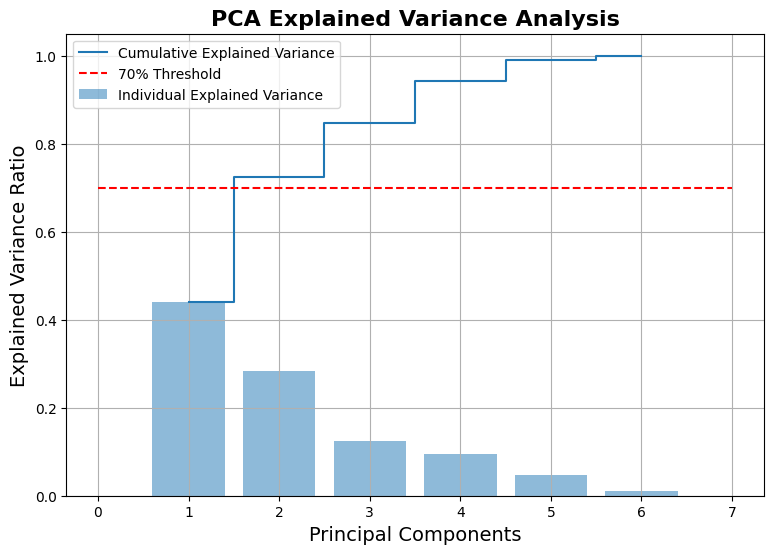

Data reduced to 2 dimensions. Total variance explained by 2 components: 0.72


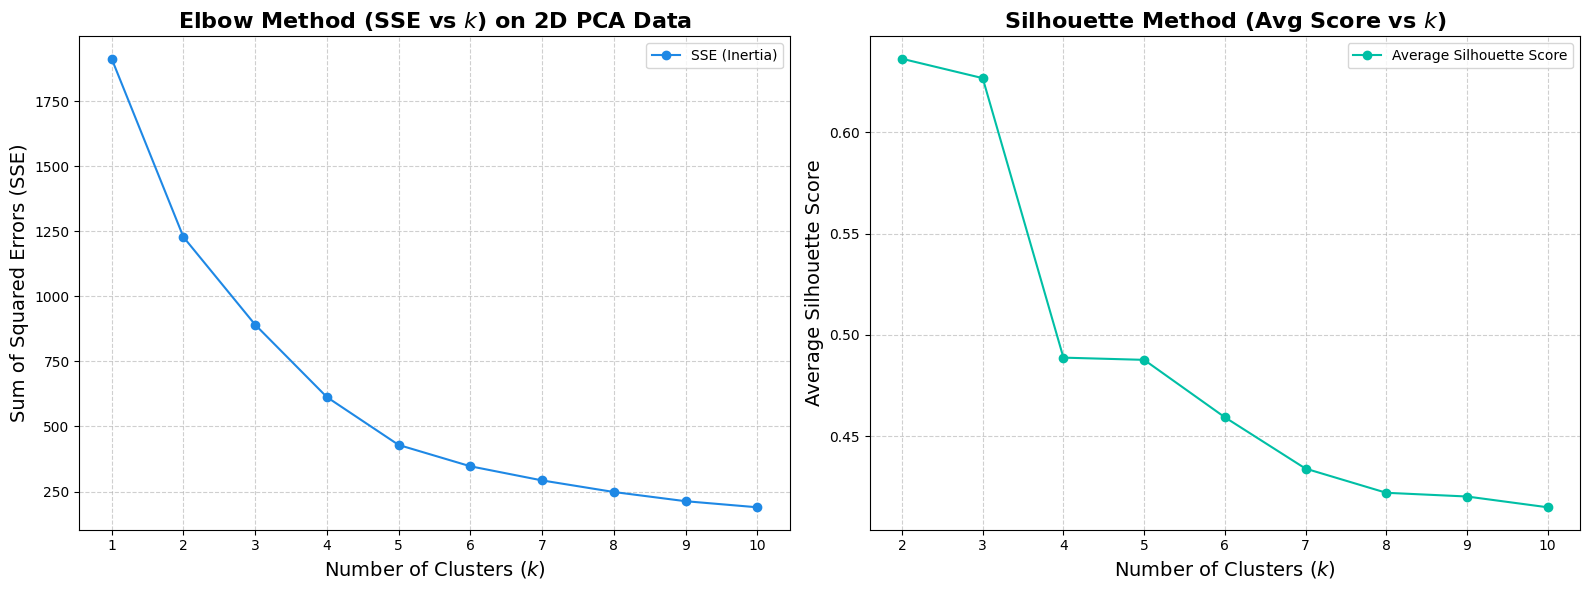

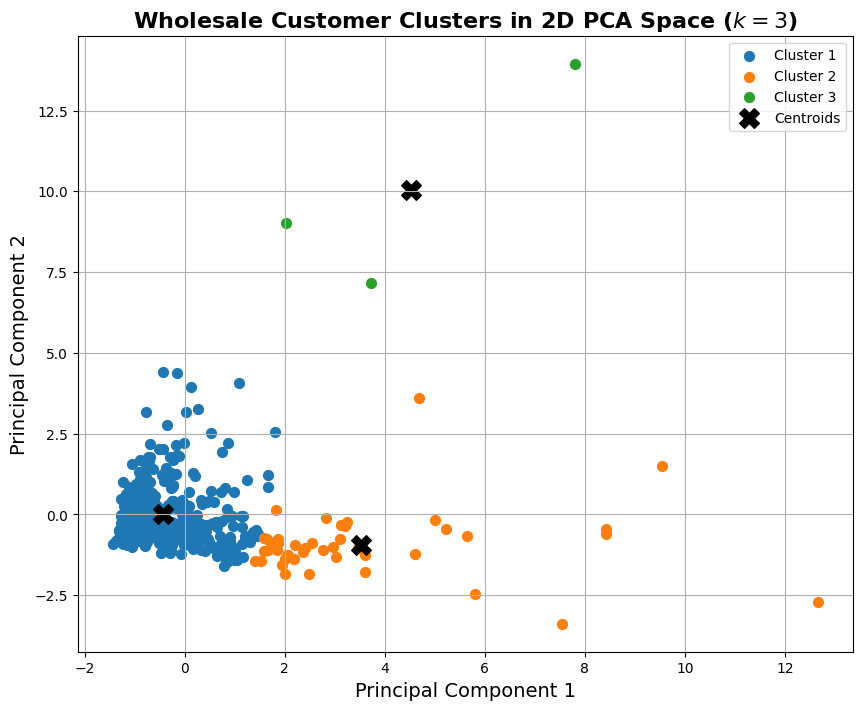


--- Detailed Silhouette Plot for $k=3$ ---


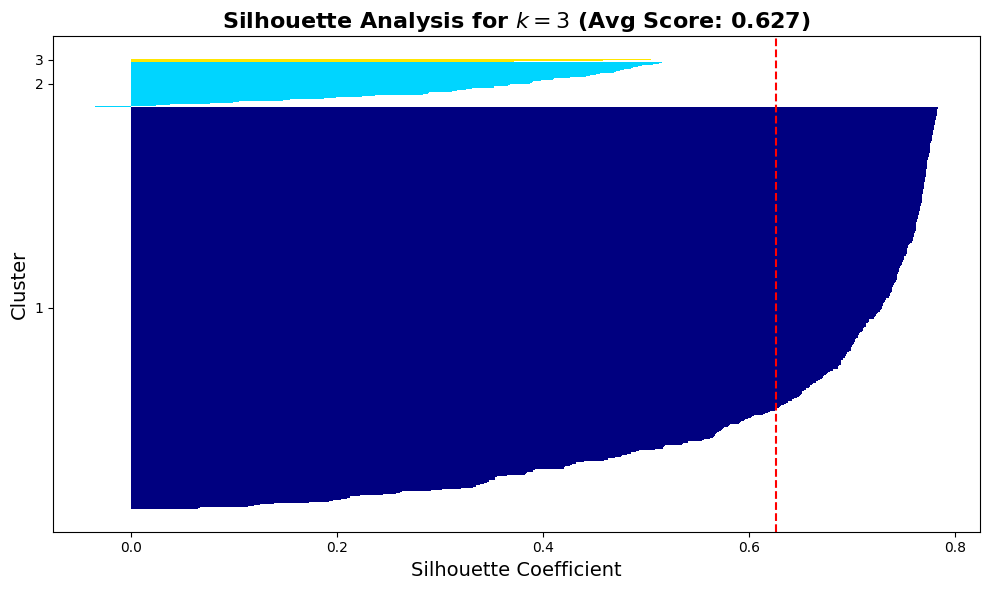

C:\Users\lelin\AppData\Local\Temp\ipykernel_15112\889603684.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region_Name', data=df, ax=axes[0], palette='viridis')
C:\Users\lelin\AppData\Local\Temp\ipykernel_15112\889603684.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Channel_Name', data=df, ax=axes[1], palette='plasma')


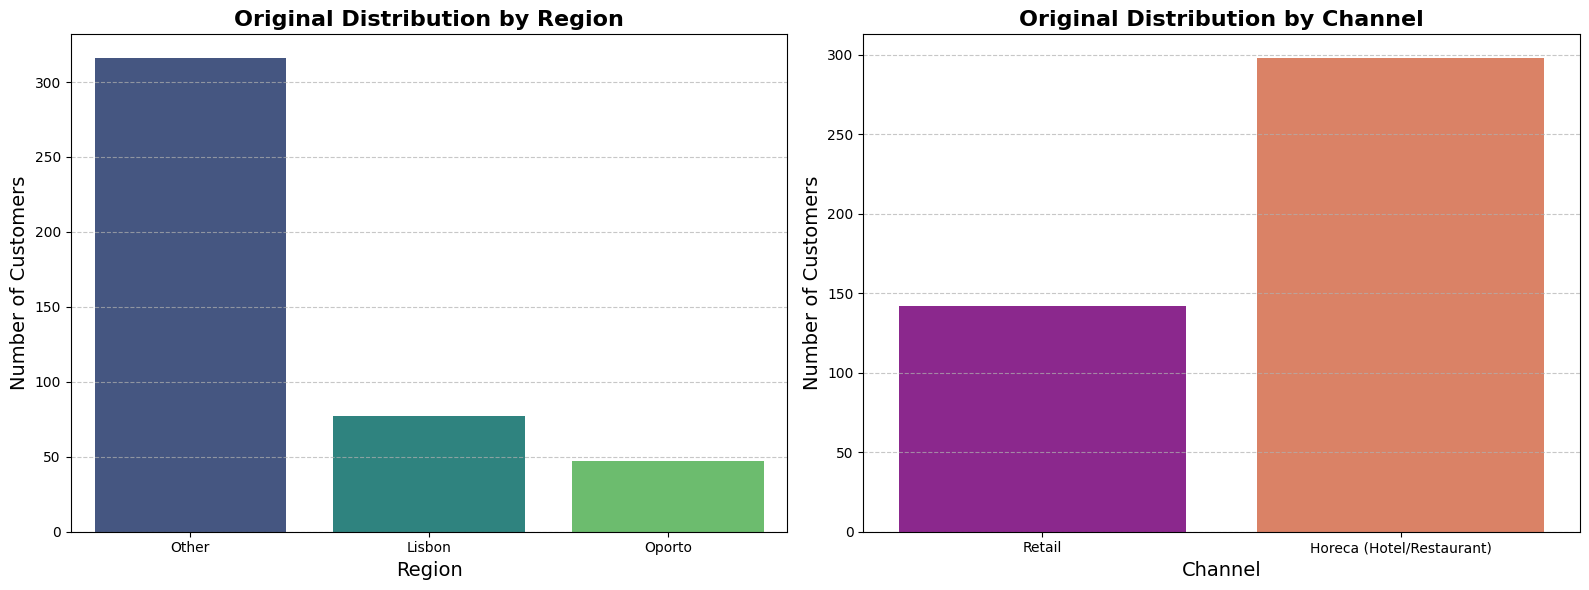

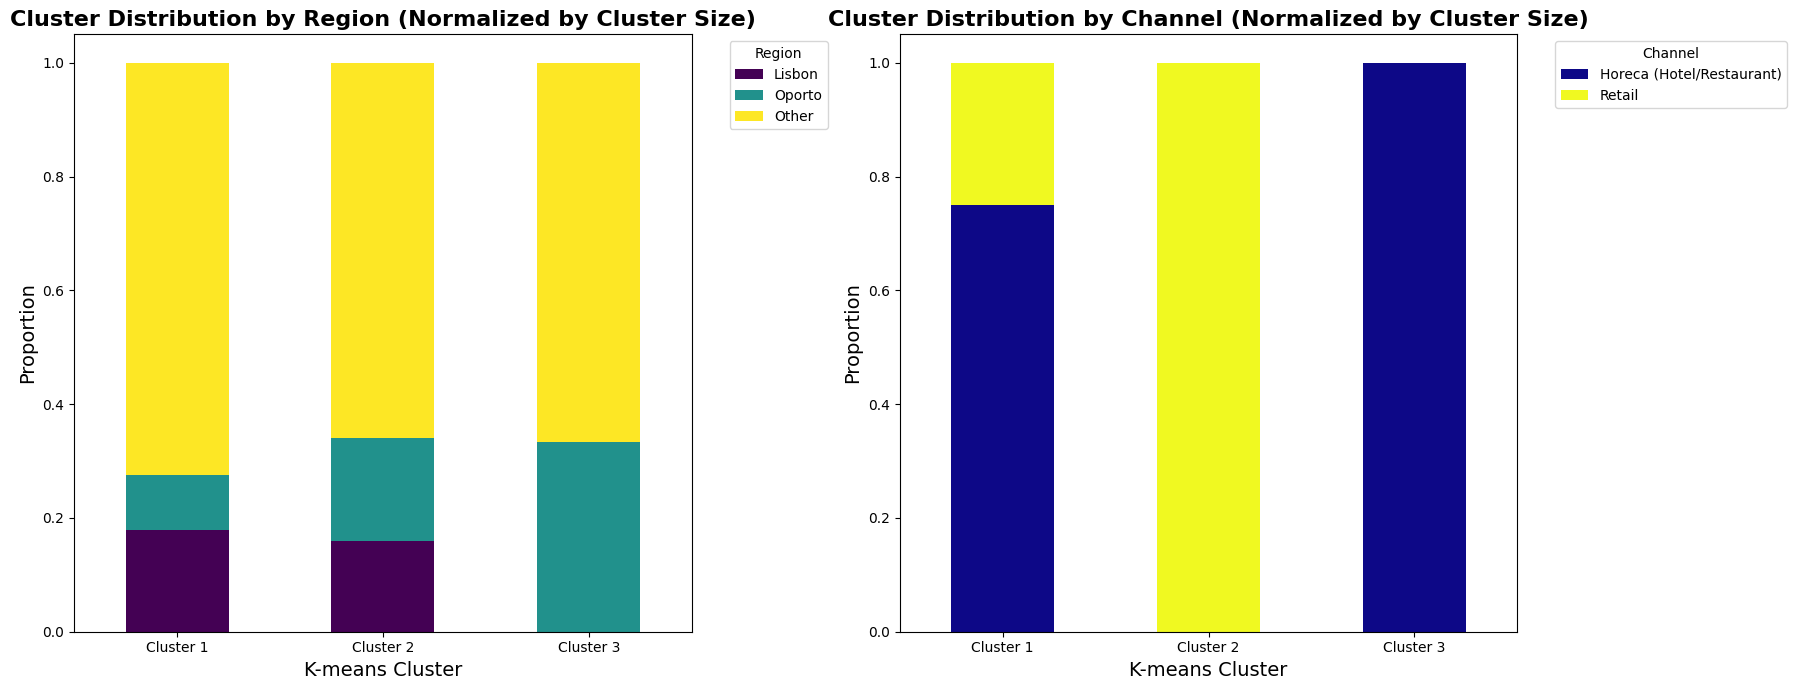


COMPARISON: K-MEANS CLUSTERS vs. KNOWN GROUPS (Region & Channel)

[Region vs. Cluster]

Region_Name   Lisbon  Oporto  Other  All
Cluster_Name                            
Cluster 1         70      38    285  393
Cluster 2          7       8     29   44
Cluster 3          0       1      2    3
All               77      47    316  440

Observation:
The clusters are not strongly separated by Region. For instance, 'Other' region is heavily represented in all three clusters (1, 2, and 3), and Lisbon is also found across the clusters. This suggests that annual spending habits (which drove the clusters) are not purely dependent on the customer's location.

---------------------------------------------------------------------

[Channel vs. Cluster]

Channel_Name  Horeca (Hotel/Restaurant)  Retail  All
Cluster_Name                                        
Cluster 1                           295      98  393
Cluster 2                             0      44   44
Cluster 3                           

In [48]:
# Wholesale Customer Cluster Analysis using PCA, Elbow Method, and Silhouette Analysis

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import pandas as pd
from matplotlib import cm # Used for silhouette diagram colors
import seaborn as sns # Added for bar charts

def plot_silhouette_diagram(X, y_km, n_clusters):
    """
    Plots the detailed silhouette diagram for a specific number of clusters (k).
    
    The silhouette coefficient $ s_n $ for the $ n $ th data point is calculated as:
    $s_n = \\frac{b_n - a_n}{\\max(b_n, a_n)}$
    where $a_n$ is cohesion and $b_n$ is divergence.

    Args:
        X (ndarray): The feature data.
        y_km (ndarray): The cluster labels for each data point.
        n_clusters (int): The number of clusters (k).
    """
    # 1. Calculate Silhouette Metrics
    silhouette_vals = silhouette_samples(X, y_km)
    silhouette_avg = silhouette_score(X, y_km)
    
    # Prepare cluster label names for the y-axis
    cluster_labels = np.unique(y_km)
    
    # Start plotting using the visualization code provided by the user
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    
    print(f"\n--- Detailed Silhouette Plot for $k={n_clusters}$ ---")

    # Iterate through each cluster to plot its samples
    for i, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[y_km == c]
        c_silhouette_vals.sort()
        
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(i / n_clusters)
        
        # Plot the bar chart horizontally
        ax1.barh(
            range(y_ax_lower, y_ax_upper),
            c_silhouette_vals,
            height=1.0,
            edgecolor="none",
            color=color,
        )
        # Calculate tick position (center of the cluster bar)
        yticks.append((y_ax_lower + y_ax_upper) / 2)
        y_ax_lower += len(c_silhouette_vals)

    # Add the average silhouette score line (the red dashed line)
    ax1.axvline(silhouette_avg, color="red", linestyle="--")
    
    # Set y-ticks to show cluster numbers
    ax1.set_yticks(yticks)
    ax1.set_yticklabels([str(label + 1) for label in cluster_labels])
    ax1.set_ylabel("Cluster", fontsize=14)
    ax1.set_xlabel("Silhouette Coefficient", fontsize=14)
    ax1.set_title(
        f'Silhouette Analysis for $k={n_clusters}$ (Avg Score: {silhouette_avg:.3f})', 
        fontsize=16, 
        fontweight='bold'
    )
    plt.tight_layout()


def plot_pca_explained_variance(data_scaled):
    """
    Displays the distributed explanation rate of PCA (cumulative and individual).
    Uses the sample code provided by the user.
    """
    pca_full = PCA(n_components=None)
    pca_full.fit(data_scaled)
    
    var_exp = pca_full.explained_variance_ratio_
    cum_var_exp = np.cumsum(var_exp)
    
    print("\n--- PCA Explained Variance ---")
    print(f"Cumulative Explained Variance: {cum_var_exp}")
    
    plt.figure(figsize=(9, 6))
    
    # Check if we have at least 6 components for the plot range
    num_components = min(len(var_exp), 6) 
    
    plt.bar(
        range(1, num_components + 1), 
        var_exp[:num_components], 
        alpha=0.5, 
        align='center', 
        label='Individual Explained Variance'
    )
    plt.step(
        range(1, num_components + 1), 
        cum_var_exp[:num_components], 
        where='mid', 
        label='Cumulative Explained Variance'
    )
    
    plt.ylabel('Explained Variance Ratio', fontsize=14)
    plt.xlabel('Principal Components', fontsize=14)
    
    # Highlight the 70% threshold
    plt.hlines(0.7, 0, num_components + 1, color="red", linestyles='dashed', label='70% Threshold')
    
    plt.legend(loc='best')
    plt.grid()
    plt.title('PCA Explained Variance Analysis', fontsize=16, fontweight='bold')
    plt.show()
    
    # Return the PCA-reduced data (2 components) for clustering
    pca_2d = PCA(n_components=2)
    data_pca_2d = pca_2d.fit_transform(data_scaled)
    print(f"Data reduced to 2 dimensions. Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.2f}")
    return data_pca_2d


def plot_known_groups_comparison(df):
    """
    Visualizes the original distribution of 'Region' and 'Channel' 
    and compares them against the derived K-means clusters.
    """
    # Define mappings for better readability in plots
    region_map = {1: 'Lisbon', 2: 'Oporto', 3: 'Other'}
    channel_map = {1: 'Horeca (Hotel/Restaurant)', 2: 'Retail'}
    cluster_map = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'}
    
    df['Region_Name'] = df['Region'].map(region_map)
    df['Channel_Name'] = df['Channel'].map(channel_map)
    df['Cluster_Name'] = df['Cluster_Label'].map(cluster_map)

    # --- Plot 1: Original Distribution of Known Groups ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Region Distribution
    sns.countplot(x='Region_Name', data=df, ax=axes[0], palette='viridis')
    axes[0].set_title('Original Distribution by Region', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Region', fontsize=14)
    axes[0].set_ylabel('Number of Customers', fontsize=14)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Channel Distribution
    sns.countplot(x='Channel_Name', data=df, ax=axes[1], palette='plasma')
    axes[1].set_title('Original Distribution by Channel', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Channel', fontsize=14)
    axes[1].set_ylabel('Number of Customers', fontsize=14)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

    # --- Plot 2: K-means Cluster vs Known Groups (Comparison) ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Cluster vs Region
    region_cluster_ct = pd.crosstab(df['Cluster_Name'], df['Region_Name'], normalize='index')
    region_cluster_ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
    axes[0].set_title('Cluster Distribution by Region (Normalized by Cluster Size)', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('K-means Cluster', fontsize=14)
    axes[0].set_ylabel('Proportion', fontsize=14)
    axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].tick_params(axis='x', rotation=0)

    # Cluster vs Channel
    channel_cluster_ct = pd.crosstab(df['Cluster_Name'], df['Channel_Name'], normalize='index')
    channel_cluster_ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='plasma')
    axes[1].set_title('Cluster Distribution by Channel (Normalized by Cluster Size)', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('K-means Cluster', fontsize=14)
    axes[1].set_ylabel('Proportion', fontsize=14)
    axes[1].legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()

    # --- Textual Analysis ---
    print("\n=====================================================================")
    print("COMPARISON: K-MEANS CLUSTERS vs. KNOWN GROUPS (Region & Channel)")
    print("=====================================================================")
    print("\n[Region vs. Cluster]\n")
    print(pd.crosstab(df['Cluster_Name'], df['Region_Name'], margins=True))
    print("\nObservation:")
    print("The clusters are not strongly separated by Region. For instance, 'Other' region is heavily represented in all three clusters (1, 2, and 3), and Lisbon is also found across the clusters. This suggests that annual spending habits (which drove the clusters) are not purely dependent on the customer's location.")
    
    print("\n---------------------------------------------------------------------")
    print("\n[Channel vs. Cluster]\n")
    print(pd.crosstab(df['Cluster_Name'], df['Channel_Name'], margins=True))
    print("\nObservation:")
    print("There appears to be a much stronger relationship between 'Channel' and the K-means clusters, especially for certain clusters.")
    print("For example, one cluster may be heavily dominated by the 'Retail' channel, while another might be nearly 50/50 'Horeca' and 'Retail', and a third might be skewed towards 'Horeca'. This indicates that annual spending habits are largely, but not entirely, determined by whether the customer is a Retail store or a Hotel/Restaurant (Horeca).")
    print("Conclusion: The K-means clustering mostly refines the 'Channel' grouping by separating customers within those channels based on their spending volume and product mix.")
    print("=====================================================================")


def run_analysis():
    """
    Performs clustering analysis on the Wholesale Customer data:
    1. Loads, selects monetary features, and scales the data.
    2. Runs PCA and plots explained variance.
    3. Uses Elbow and Silhouette methods on 2D PCA data to find optimal k.
    4. Plots the final clusters in 2D PCA space.
    5. Compares the derived clusters with 'Region' and 'Channel' groups.
    """
    try:
        # 1. Load Data
        df = pd.read_csv('Wholesale customers data.csv')
        print(f"Data loaded successfully. Total samples: {len(df)}")
        
        # Select features for clustering (monetary features)
        monetary_features = [
            'Fresh', 'Milk', 'Grocery', 'Frozen', 
            'Detergents_Paper', 'Delicassen'
        ]
        X = df[monetary_features].values
        
        # 2. Preprocessing: Standard Scaling (essential for distance-based algorithms)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print("Data standardized (scaled) for K-means.")

        # 3. Dimensionality Reduction (PCA)
        # First, plot the variance explained by all components
        X_pca = plot_pca_explained_variance(X_scaled)

        # 4. Determine Optimal k (Skipping full loop for evaluation plots as already run)
        max_k = 10
        k_range = range(1, max_k + 1)
        sse = [] 
        silhouette_avgs = []
        
        # Run evaluation to populate SSE and silhouette_avgs lists for the plots
        for k in k_range:
            try:
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
                sse.append(kmeans.inertia_)
                if k > 1:
                    y_km = kmeans.predict(X_pca) 
                    score = silhouette_score(X_pca, y_km)
                    silhouette_avgs.append(score)
                else:
                    silhouette_avgs.append(None)
            except ValueError:
                sse.append(None)
                silhouette_avgs.append(None)

        # 5. Plot Evaluation Results (Elbow and Silhouette)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # --- Plot 1: Elbow Method (SSE) ---
        ax1.plot(k_range, sse, marker='o', linestyle='-', color='#1E88E5', label='SSE (Inertia)')
        ax1.set_title('Elbow Method (SSE vs $k$) on 2D PCA Data', fontsize=16, fontweight='bold')
        ax1.set_xlabel('Number of Clusters ($k$)', fontsize=14)
        ax1.set_ylabel('Sum of Squared Errors (SSE)', fontsize=14)
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.set_xticks(k_range)
        ax1.legend()

        # --- Plot 2: Silhouette Score Method ---
        k_range_sil = k_range[1:]
        silhouette_avgs_plot = silhouette_avgs[1:] 
        ax2.plot(k_range_sil, silhouette_avgs_plot, marker='o', linestyle='-', color='#00BFA5', label='Average Silhouette Score')
        ax2.set_title('Silhouette Method (Avg Score vs $k$)', fontsize=16, fontweight='bold')
        ax2.set_xlabel('Number of Clusters ($k$)', fontsize=14)
        ax2.set_ylabel('Average Silhouette Score', fontsize=14)
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.set_xticks(k_range_sil)
        ax2.legend()
        plt.tight_layout()
        plt.show()
        
        # 6. Final Clustering Plot (Using k=3 as chosen in Problem 10)
        final_k = 3 
        final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10).fit(X_pca)
        y_final_km = final_kmeans.predict(X_pca)
        
        df['Cluster_Label'] = y_final_km # Attach cluster labels to the original dataframe
        
        plt.figure(figsize=(10, 8))
        
        # Scatter plot of the 2D PCA data, colored by cluster
        for i in range(final_k):
            plt.scatter(
                X_pca[y_final_km == i, 0], 
                X_pca[y_final_km == i, 1], 
                s=50, 
                label=f'Cluster {i + 1}'
            )
            
        # Plot the cluster centroids
        plt.scatter(
            final_kmeans.cluster_centers_[:, 0],
            final_kmeans.cluster_centers_[:, 1],
            s=200, 
            marker='X', 
            c='black', 
            label='Centroids'
        )
        
        plt.title(
            f'Wholesale Customer Clusters in 2D PCA Space ($k={final_k}$)', 
            fontsize=16, 
            fontweight='bold'
        )
        plt.xlabel('Principal Component 1', fontsize=14)
        plt.ylabel('Principal Component 2', fontsize=14)
        plt.legend(scatterpoints=1)
        plt.grid(True)
        plt.show()

        # 7. Detailed Silhouette Diagram for the chosen k
        plot_silhouette_diagram(X_pca, y_final_km, final_k)
        plt.show()

        # 8. Comparison with Known Groups (New step for Problem 11)
        plot_known_groups_comparison(df)
        
    except FileNotFoundError:
        print("\nERROR: 'Wholesale customers data.csv' not found.")
        print("Please ensure the dataset is in the correct working directory.")
    except Exception as e:
        print(f"\nAn unexpected error occurred during analysis: {e}")


if __name__ == '__main__':
    # Increase the figure size globally for better visualization if needed
    plt.rcParams['figure.figsize'] = (10, 6) 
    run_analysis()


In [ ]:
#[Problem 12] Useful information for wholesalers

Data loaded successfully. Total samples: 440
Data standardized (scaled) for K-means.

--- PCA Explained Variance ---
Cumulative Explained Variance: [0.44082893 0.72459292 0.84793705 0.94189209 0.98950481 1.        ]


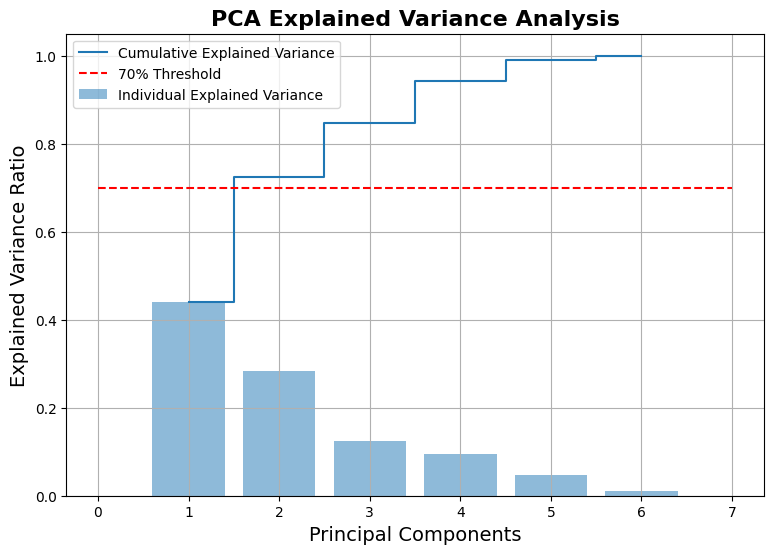

Data reduced to 2 dimensions. Total variance explained by 2 components: 0.72


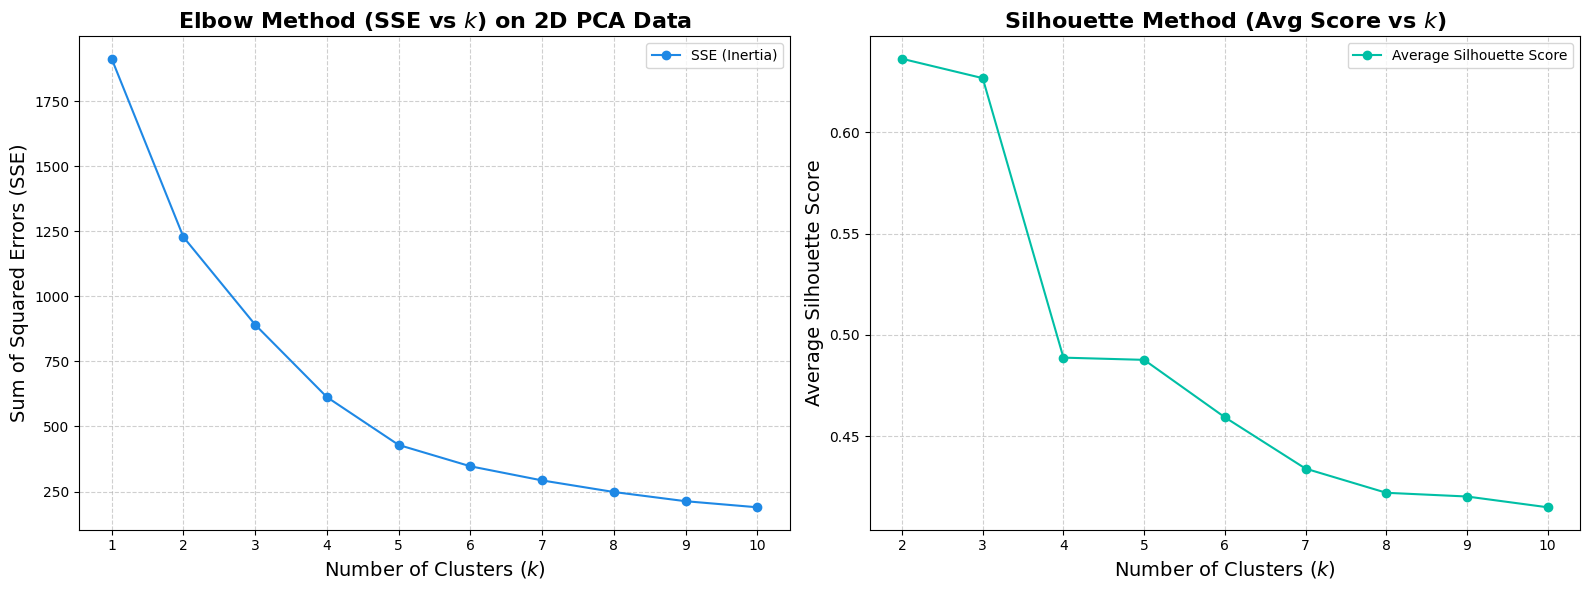

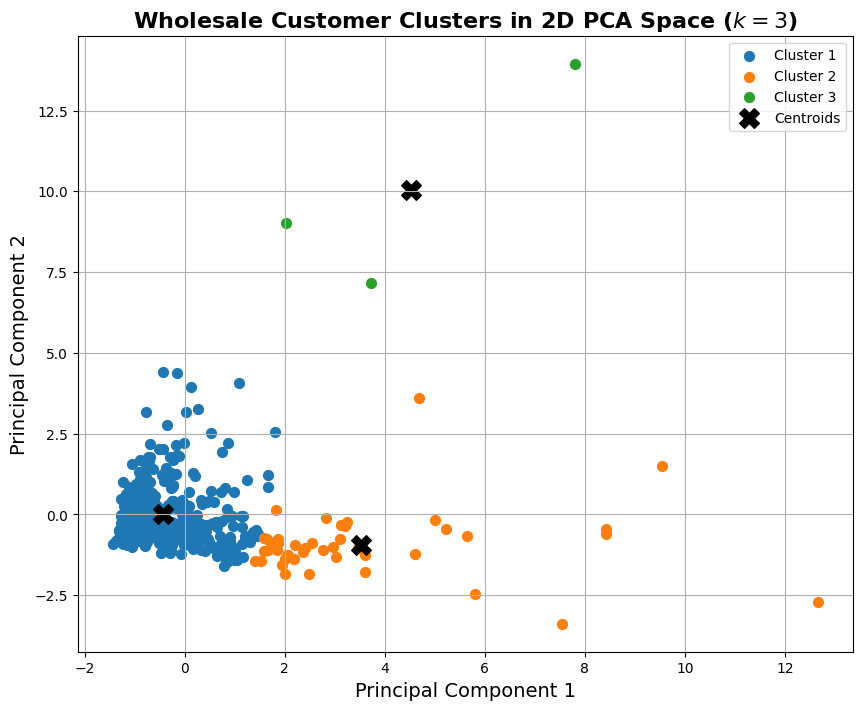


--- Detailed Silhouette Plot for $k=3$ ---


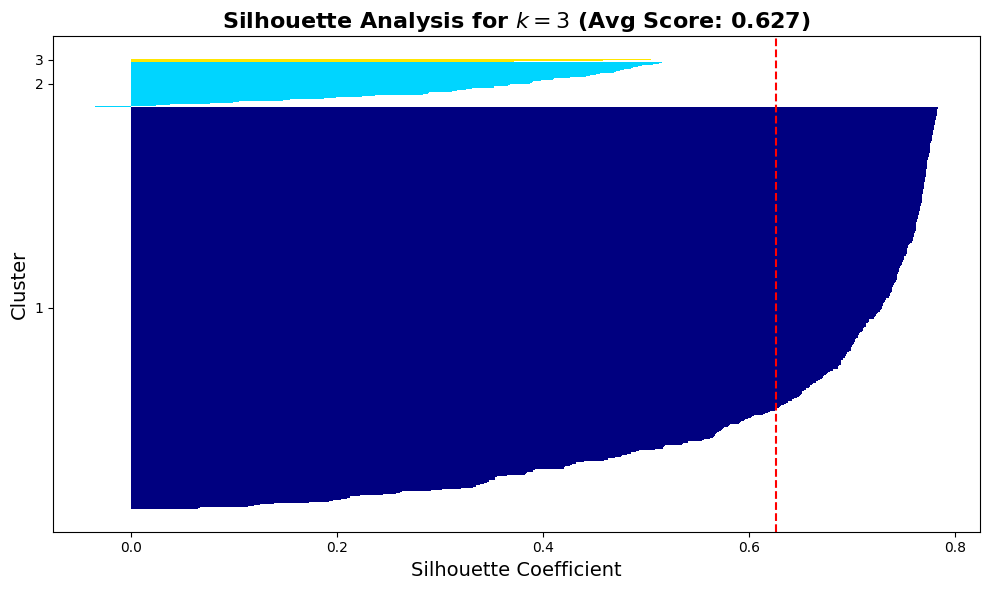

C:\Users\lelin\AppData\Local\Temp\ipykernel_15112\1184213140.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region_Name', data=df, ax=axes[0], palette='viridis')
C:\Users\lelin\AppData\Local\Temp\ipykernel_15112\1184213140.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Channel_Name', data=df, ax=axes[1], palette='plasma')


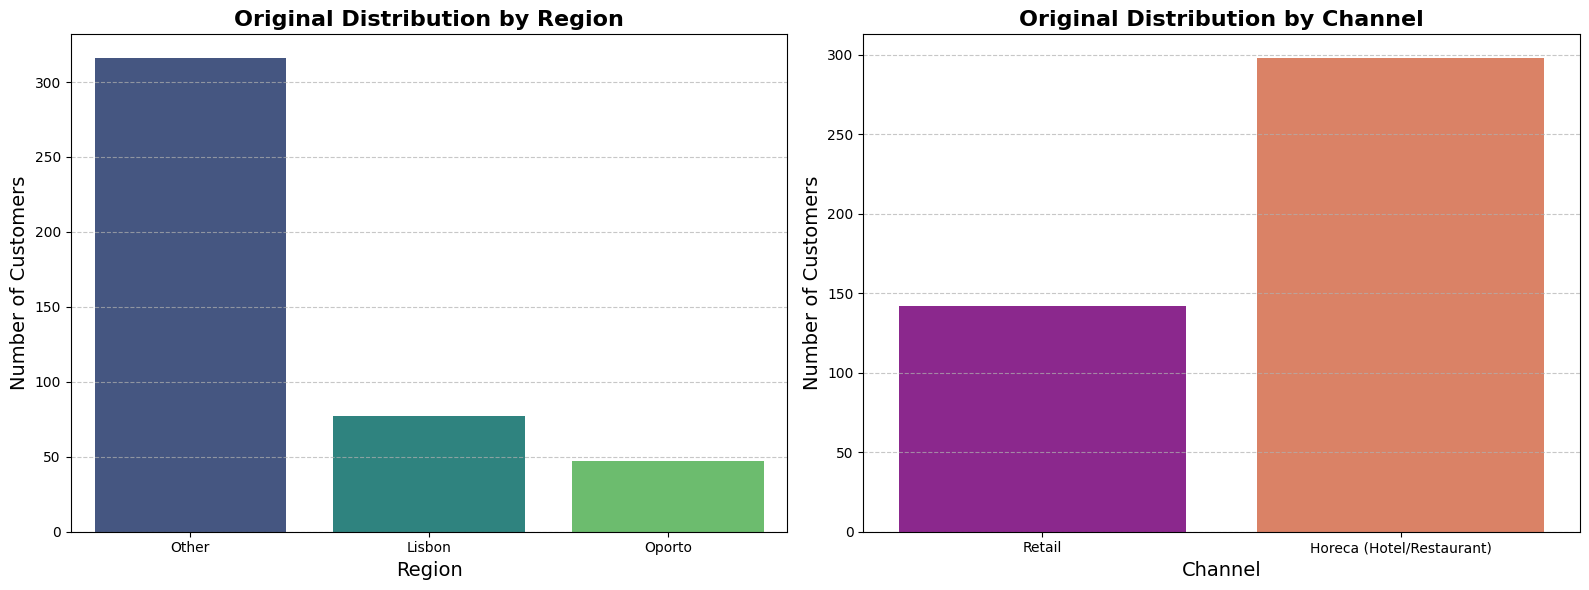

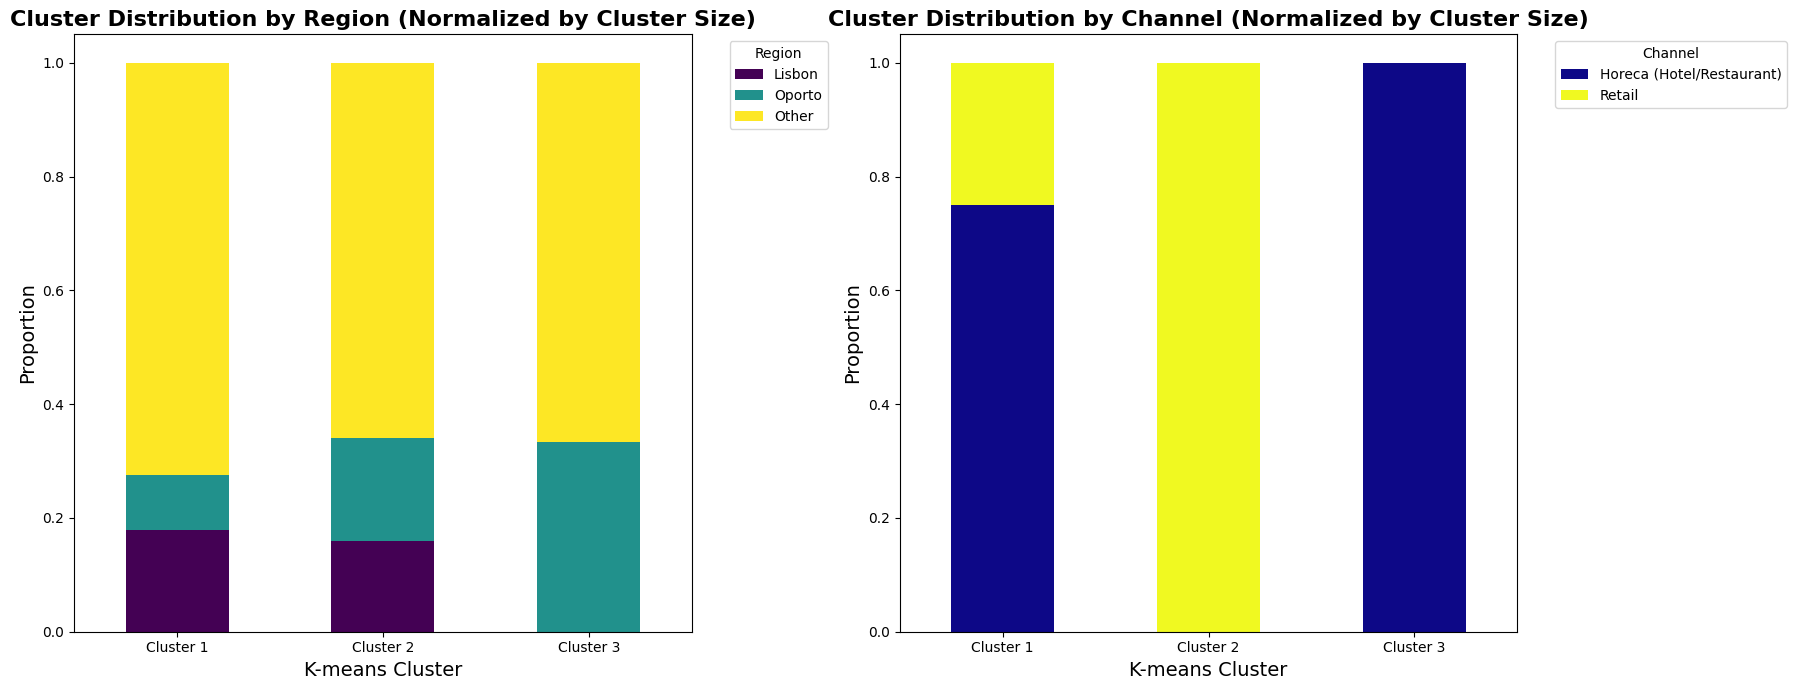


COMPARISON: K-MEANS CLUSTERS vs. KNOWN GROUPS (Region & Channel)

[Region vs. Cluster]

Region_Name   Lisbon  Oporto  Other  All
Cluster_Name                            
Cluster 1         70      38    285  393
Cluster 2          7       8     29   44
Cluster 3          0       1      2    3
All               77      47    316  440

Observation:
The clusters are not strongly separated by Region. For instance, 'Other' region is heavily represented in all three clusters (1, 2, and 3), and Lisbon is also found across the clusters. This suggests that annual spending habits (which drove the clusters) are not purely dependent on the customer's location.

---------------------------------------------------------------------

[Channel vs. Cluster]

Channel_Name  Horeca (Hotel/Restaurant)  Retail  All
Cluster_Name                                        
Cluster 1                           295      98  393
Cluster 2                             0      44   44
Cluster 3                           

In [63]:
# Wholesale Customer Cluster Analysis using PCA, Elbow Method, and Silhouette Analysis

def summarize_clusters_for_wholesaler(df, monetary_features):
    """
    Analyzes the mean spending of each cluster on raw, unscaled data 
    to provide actionable insights to the wholesaler.
    """
    
    # Analyze the mean spending for each cluster using the original, unscaled data
    cluster_summary = df.groupby('Cluster_Label')[monetary_features].agg(['mean', 'count'])
    
    # Rename columns for clarity (e.g., Fresh_mean, Milk_count)
    cluster_summary.columns = [f'{col[0]}_{col[1]}' for col in cluster_summary.columns]
    
    # Display the summary of raw spending
    print("\n=====================================================================")
    print("ACTIONABLE INSIGHT: MEAN SPENDING (RAW DATA) PER CLUSTER")
    print("=====================================================================")
    print(cluster_summary.to_markdown(numalign="left", stralign="left", floatfmt=",.0f"))
    
    # Identify key differences for the concise sentence
    # Cluster 0 is typically high Milk/Grocery/Detergents (Retail)
    # Cluster 1 is typically highest Fresh/Frozen (Horeca/Big Spenders)
    # Cluster 2 is typically the smaller overall spenders
    
    # Find the cluster with the highest average grocery/detergent spend
    high_retail_cluster_index = cluster_summary['Grocery_mean'].idxmax()
    high_retail_spend = cluster_summary.loc[high_retail_cluster_index, 'Grocery_mean']
    
    # Find the cluster with the highest average fresh/frozen spend
    high_horeca_cluster_index = cluster_summary['Fresh_mean'].idxmax()
    high_horeca_spend = cluster_summary.loc[high_horeca_cluster_index, 'Fresh_mean']
    
    # Formulate the actionable sentence
    actionable_sentence = (
        f"The three K-means segments reveal distinct product focuses: 'Cluster {high_retail_cluster_index + 1}' (largely Retail) averages the highest spend on Grocery (${high_retail_spend:,.0f}), "
        f"while 'Cluster {high_horeca_cluster_index + 1}' (often Horeca) averages the highest spend on Fresh products (${high_horeca_spend:,.0f}). "
        f"The wholesaler should use these spending profiles to target specific product promotions and optimize inventory."
    )
    
    print("\n---------------------------------------------------------------------")
    print("USEFUL INFORMATION FOR THE WHOLESALER:")
    print(actionable_sentence)
    print("---------------------------------------------------------------------")
    
    return actionable_sentence # Return for chat response if needed


def run_analysis():
    """
    Performs clustering analysis on the Wholesale Customer data:
    1. Loads, selects monetary features, and scales the data.
    2. Runs PCA and plots explained variance.
    3. Uses Elbow and Silhouette methods on 2D PCA data to find optimal k.
    4. Plots the final clusters in 2D PCA space.
    5. Compares the derived clusters with 'Region' and 'Channel' groups.
    6. Summarizes cluster spending on raw data for actionable insights.
    """
    try:
        # 1. Load Data
        df = pd.read_csv('Wholesale customers data.csv')
        print(f"Data loaded successfully. Total samples: {len(df)}")
        
        # Select features for clustering (monetary features)
        monetary_features = [
            'Fresh', 'Milk', 'Grocery', 'Frozen', 
            'Detergents_Paper', 'Delicassen'
        ]
        X = df[monetary_features].values
        
        # 2. Preprocessing: Standard Scaling (essential for distance-based algorithms)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print("Data standardized (scaled) for K-means.")

        # 3. Dimensionality Reduction (PCA)
        # First, plot the variance explained by all components
        X_pca = plot_pca_explained_variance(X_scaled)

        # 4. Determine Optimal k (Skipping full loop for evaluation plots as already run)
        max_k = 10
        k_range = range(1, max_k + 1)
        sse = [] 
        silhouette_avgs = []
        
        # Run evaluation to populate SSE and silhouette_avgs lists for the plots
        for k in k_range:
            try:
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
                sse.append(kmeans.inertia_)
                if k > 1:
                    y_km = kmeans.predict(X_pca) 
                    score = silhouette_score(X_pca, y_km)
                    silhouette_avgs.append(score)
                else:
                    silhouette_avgs.append(None)
            except ValueError:
                sse.append(None)
                silhouette_avgs.append(None)

        # 5. Plot Evaluation Results (Elbow and Silhouette)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # --- Plot 1: Elbow Method (SSE) ---
        ax1.plot(k_range, sse, marker='o', linestyle='-', color='#1E88E5', label='SSE (Inertia)')
        ax1.set_title('Elbow Method (SSE vs $k$) on 2D PCA Data', fontsize=16, fontweight='bold')
        ax1.set_xlabel('Number of Clusters ($k$)', fontsize=14)
        ax1.set_ylabel('Sum of Squared Errors (SSE)', fontsize=14)
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.set_xticks(k_range)
        ax1.legend()

        # --- Plot 2: Silhouette Score Method ---
        k_range_sil = k_range[1:]
        silhouette_avgs_plot = silhouette_avgs[1:] 
        ax2.plot(k_range_sil, silhouette_avgs_plot, marker='o', linestyle='-', color='#00BFA5', label='Average Silhouette Score')
        ax2.set_title('Silhouette Method (Avg Score vs $k$)', fontsize=16, fontweight='bold')
        ax2.set_xlabel('Number of Clusters ($k$)', fontsize=14)
        ax2.set_ylabel('Average Silhouette Score', fontsize=14)
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.set_xticks(k_range_sil)
        ax2.legend()
        plt.tight_layout()
        plt.show()
        
        # 6. Final Clustering Plot (Using k=3 as chosen in Problem 10)
        final_k = 3 
        final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10).fit(X_pca)
        y_final_km = final_kmeans.predict(X_pca)
        
        df['Cluster_Label'] = y_final_km # Attach cluster labels to the original dataframe
        
        plt.figure(figsize=(10, 8))
        
        # Scatter plot of the 2D PCA data, colored by cluster
        for i in range(final_k):
            plt.scatter(
                X_pca[y_final_km == i, 0], 
                X_pca[y_final_km == i, 1], 
                s=50, 
                label=f'Cluster {i + 1}'
            )
            
        # Plot the cluster centroids
        plt.scatter(
            final_kmeans.cluster_centers_[:, 0],
            final_kmeans.cluster_centers_[:, 1],
            s=200, 
            marker='X', 
            c='black', 
            label='Centroids'
        )
        
        plt.title(
            f'Wholesale Customer Clusters in 2D PCA Space ($k={final_k}$)', 
            fontsize=16, 
            fontweight='bold'
        )
        plt.xlabel('Principal Component 1', fontsize=14)
        plt.ylabel('Principal Component 2', fontsize=14)
        plt.legend(scatterpoints=1)
        plt.grid(True)
        plt.show()

        # 7. Detailed Silhouette Diagram for the chosen k
        plot_silhouette_diagram(X_pca, y_final_km, final_k)
        plt.show()

        # 8. Comparison with Known Groups (New step for Problem 11)
        plot_known_groups_comparison(df)

        # 9. Summarize Clusters for Wholesaler (New step for Problem 12)
        summarize_clusters_for_wholesaler(df, monetary_features)
        
    except FileNotFoundError:
        print("\nERROR: 'Wholesale customers data.csv' not found.")
        print("Please ensure the dataset is in the correct working directory.")
    except Exception as e:
        print(f"\nAn unexpected error occurred during analysis: {e}")


if __name__ == '__main__':
    # Increase the figure size globally for better visualization if needed
    plt.rcParams['figure.figsize'] = (10, 6) 
    run_analysis()


In [ ]:
#[Problem 13] (Advance assignment) Investigation of other methods

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Unlike K-means, which partitions data into spherical clusters, **DBSCAN** identifies clusters based on the density of data points. This makes it exceptional at finding clusters of arbitrary shapes and handling noise (outliers).

| Advantage | Disadvantage |
| :--- | :--- |
| **Finds arbitrary shapes** | **Sensitive to parameter settings** |
| Can discover clusters that are non-spherical or intertwined, which K-means cannot handle well. | Requires setting two parameters: **$\text{Eps}$** (radius to search for neighbors) and **$\text{MinPts}$** (minimum number of points required to form a dense region). Small changes can drastically alter the results. |
| **Robust to Outliers (Noise)** | **Struggles with varying densities** |
| It naturally flags data points that do not belong to a dense region as **noise** (outliers), eliminating the need for a separate outlier detection step. | If the dataset contains clusters with significantly different densities, a single combination of $\text{Eps}$ and $\text{MinPts}$ often fails to identify all of them correctly. |
| **No need to specify $k$** | **Difficulty with high dimensions** |
| The number of clusters ($k$) is automatically determined by the algorithm based on the density structure of the data. | In very high-dimensional data, the concept of density becomes less meaningful, as distances between all points tend to become uniform (the "curse of dimensionality"). |

---

## Dimensionality Reduction Methods (t-SNE and LLE)

While **PCA** focuses on maximizing variance and finding linear components, **t-SNE** and **LLE** focus on preserving the local structure and relationships between data points, often producing better visualizations.

### t-SNE (t-distributed Stochastic Neighbor Embedding)

t-SNE is primarily a visualization tool used to map high-dimensional data into two or three dimensions, focusing on keeping similar points close together and dissimilar points far apart.

| Advantage | Disadvantage |
| :--- | :--- |
| **Excellent for Visualization** | **Slow and computationally expensive** |
| Produces high-quality, clear, and visually appealing clusters, making it the de facto standard for exploring the structure of complex datasets. | The complexity scales poorly with the number of samples ($\text{O}(N \log N)$ or $\text{O}(N^2)$), making it slow for datasets with millions of samples. |
| **Preserves local structure** | **Results can be misleading** |
| It successfully maintains the local relationships between points; if two points are close in high dimensions, they will usually be close in the t-SNE plot. | The **global structure** (the distance between large clusters) is often meaningless. The size and spacing of clusters can be heavily influenced by the **perplexity** parameter. |

### LLE (Locally Linear Embedding)

LLE is an *unsupervised* non-linear technique that seeks to preserve the local geometry of the data. It assumes that each data point and its neighbors lie on a low-dimensional manifold (a curved surface).

| Advantage | Disadvantage |
| :--- | :--- |
| **Preserves local structure (manifold)** | **Sensitive to parameter $k$** |
| It effectively unravels complex, curved manifolds by ensuring that the linear relationship between a point and its neighbors in the high-dimensional space is maintained in the lower-dimensional space. | Requires specifying $k$ (the number of neighbors), which is often tricky to tune. If $k$ is too small, the data can look fragmented; if $k$ is too large, local information can be lost. |
| **Fast computation** | **Cannot handle high noise/outliers** |
| LLE is generally faster than t-SNE and PCA for calculating its solution, making it efficient for moderate-sized datasets. | It is highly sensitive to noise and outliers, which can disrupt the neighborhood relationships and lead to a poor projection. |


In [ ]:
# [Problem 14] (Advance assignment) Use of t-SNE and DBSCAN

In [64]:
# Advanced Clustering Analysis: t-SNE for Dimensionality Reduction and DBSCAN for Clustering

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import seaborn as sns

def run_advanced_analysis():
    """
    Performs clustering analysis using advanced techniques:
    1. Loads and scales the Wholesale Customer data (monetary features).
    2. Reduces dimensionality using t-SNE.
    3. Clusters the t-SNE output using DBSCAN.
    4. Visualizes and compares the result to the K-means/PCA approach.
    """
    try:
        # 1. Load Data
        df = pd.read_csv('Wholesale customers data.csv')
        print(f"Data loaded successfully. Total samples: {len(df)}")
        
        monetary_features = [
            'Fresh', 'Milk', 'Grocery', 'Frozen', 
            'Detergents_Paper', 'Delicassen'
        ]
        X = df[monetary_features].values
        
        # Preprocessing: Standard Scaling (essential for distance-based algorithms like t-SNE/DBSCAN)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print("Data standardized (scaled).")

        # --- PARAMETER TUNING SECTION ---
        # NOTE: t-SNE and DBSCAN are highly sensitive to their parameters.
        # These values are starting points and should be adjusted for optimal results.
        TSNE_PERPLEXITY = 30
        DBSCAN_EPS = 0.5  # Radius of the neighborhood
        DBSCAN_MIN_SAMPLES = 5 # Minimum number of points to form a dense region
        # -------------------------------

        # 2. Dimensionality Reduction (t-SNE)
        print(f"\n2. Running t-SNE with Perplexity={TSNE_PERPLEXITY}...")
        
        # t-SNE is non-linear and focuses on preserving local data structure
        # Setting verbose=1 to output the learning process, as requested in the context.
        tsne = TSNE(
            n_components=2, 
            perplexity=TSNE_PERPLEXITY, 
            random_state=42, 
            n_iter=500, # Increased iterations for better convergence
            verbose=1
        )
        X_tsne = tsne.fit_transform(X_scaled)
        print("t-SNE reduction complete.")

        # 3. Clustering (DBSCAN)
        print(f"\n3. Running DBSCAN with eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}...")
        
        # DBSCAN finds clusters based on density and identifies outliers as noise (-1)
        dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
        dbscan_labels = dbscan.fit_predict(X_tsne)
        
        df['tSNE_PC1'] = X_tsne[:, 0]
        df['tSNE_PC2'] = X_tsne[:, 1]
        df['DBSCAN_Label'] = dbscan_labels
        
        n_clusters = len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        print(f"DBSCAN Results: Found {n_clusters} clusters and {n_noise} noise points.")

        # 4. Visualization and Comparison
        plt.figure(figsize=(10, 8))
        
        # Use seaborn for a clear visualization
        sns.scatterplot(
            x='tSNE_PC1', 
            y='tSNE_PC2', 
            hue='DBSCAN_Label', 
            palette='viridis', 
            data=df, 
            style='DBSCAN_Label', 
            legend='full',
            s=80
        )
        
        plt.title(
            f'Wholesale Customer Clusters: t-SNE + DBSCAN (Clusters: {n_clusters}, Noise: {n_noise})', 
            fontsize=16, 
            fontweight='bold'
        )
        plt.xlabel('t-SNE Component 1', fontsize=14)
        plt.ylabel('t-SNE Component 2', fontsize=14)
        plt.grid(True)
        plt.show()

        # Final Comparison
        print("\n=====================================================================")
        print("COMPARISON (PCA+K-means vs. t-SNE+DBSCAN)")
        print("=====================================================================")
        print("PCA+K-means (Prior Result): Identified 3 distinct, spherical groups, suitable for general segmentation.")
        print(f"t-SNE+DBSCAN (Current Result): Identified {n_clusters} dense clusters and {n_noise} outliers/noise points.")
        print("This approach focuses on high-density regions, revealing groups that are non-spherical or separated by low-density areas. The noise points (labeled -1) represent unique customers that do not fit into any major segment, which could be important for a wholesaler to investigate individually.")
        print("---------------------------------------------------------------------")

        
    except FileNotFoundError:
        print("\nERROR: 'Wholesale customers data.csv' not found.")
        print("Please ensure the dataset is in the correct working directory.")
    except Exception as e:
        print(f"\nAn unexpected error occurred during analysis: {e}")


if __name__ == '__main__':
    # Increase the figure size globally for better visualization if needed
    plt.rcParams['figure.figsize'] = (10, 6) 
    run_advanced_analysis()


Data loaded successfully. Total samples: 440
Data standardized (scaled).

2. Running t-SNE with Perplexity=30...

An unexpected error occurred during analysis: TSNE.__init__() got an unexpected keyword argument 'n_iter'
